# Data Postprocessing

In [ ]:
import glob
import os
import pickle
import re
import numpy as np

# --- KONFIGURASI PATH ---
folder_path = "checkpoint_jobs"  # Pastikan path ini benar
# Pola file awal (menangkap semua .pkl)
file_pattern = os.path.join(folder_path, "*.pkl")

print(f"📂 Target direktori: {folder_path}")

📂 Target direktori: checkpoint_jobs

--- [1] MEMULAI PROSES RENAME FILE ---
ℹ️ Tidak ada file yang perlu di-rename (atau nama file sudah format baru).

--- [2] MEMULAI PROSES AGREGASI DATA ---
✅ Data tersusun untuk objectives: ['itse', 'ise', 'iae', 'itae']
💾 Menyimpan file .pkl rekapitulasi...
🚀 SELESAI!


In [ ]:
# ==========================================
# BAGIAN 1: RENAME FILE OTOMATIS
# ==========================================
print("\n--- [1] MEMULAI PROSES RENAME FILE ---")

# Mapping dari nama lama ke nama baru
rename_map = {
    "ciae": "iae",
    "cise": "ise",
    "citae": "itae",
    "citse": "itse"
    # Tambahkan mapping lain jika ada variasi lain (misal: "hoa_cappiello" -> "hoa")
}

files = glob.glob(file_pattern)
renamed_count = 0

for filepath in files:
    filename = os.path.basename(filepath)
    new_filename = filename
    
    # Cek apakah filename mengandung salah satu key dari map
    for old_str, new_str in rename_map.items():
        if old_str in filename:
            new_filename = filename.replace(old_str, new_str)
            break  # Pindah ke file berikutnya setelah match
    
    # Lakukan rename jika nama berubah
    if new_filename != filename:
        old_path = os.path.join(folder_path, filename)
        new_path = os.path.join(folder_path, new_filename)
        
        try:
            os.rename(old_path, new_path)
            # print(f"✅ Renamed: {filename} -> {new_filename}") # Uncomment jika ingin log per file
            renamed_count += 1
        except OSError as e:
            print(f"❌ Gagal rename {filename}: {e}")

if renamed_count > 0:
    print(f"✨ Sukses mengubah nama {renamed_count} file.")
else:
    print("ℹ️ Tidak ada file yang perlu di-rename (atau nama file sudah format baru).")

In [ ]:
# ==========================================
# BAGIAN 2: AGREGASI DATA (LOGIKA UTAMA)
# ==========================================
print("\n--- [2] MEMULAI PROSES AGREGASI DATA ---")

# Update pattern agar hanya mengambil file yang sudah sesuai format baru
# Format target: acc_run_0_ga_ciae.pkl
# Regex: (System)_run_(ID)_(Algo)_(Objective).pkl
files = glob.glob(file_pattern) 
filename_regex = re.compile(r"(.+)_run_(\d+)_([^_]+)_([^_]+)\.pkl")

temp_data = []

for filepath in files:
    filename = os.path.basename(filepath)
    match = filename_regex.match(filename)
    
    if match:
        # Group 1: System (misal: acc)
        # Group 2: Run ID (misal: 0)
        # Group 3: Algo (misal: ga)
        # Group 4: Objective (sekarang 'ciae', 'citae', dll)
        
        run_id = int(match.group(2))
        algo = match.group(3).lower()
        obj = match.group(4).lower()
        
        try:
            with open(filepath, 'rb') as f:
                content = pickle.load(f)
                
            temp_data.append({
                "obj": obj,
                "algo": algo,
                "run_id": run_id,
                "fitness": content.get('best_fitness'),
                "solution": content.get('best_solution'),
                "curve": content.get('curve')
            })
        except Exception as e:
            print(f"⚠️ Error reading {filename}: {e}")
    else:
        # Optional: Print file yang tidak match regex (untuk debug)
        # print(f"Skipping file (format tidak sesuai): {filename}")
        pass

# --- RESTRUKTURISASI & SORTING ---
if not temp_data:
    print("❌ Tidak ada data yang berhasil diparsing! Cek kembali nama file atau regex.")
else:
    all_best_fitnesses = {}
    all_best_solutions = {}
    all_curves = {}

    unique_objs = set(x['obj'] for x in temp_data)
    
    for obj in unique_objs:
        all_best_fitnesses[obj] = {}
        all_best_solutions[obj] = {}
        all_curves[obj] = {}
        
        obj_items = [x for x in temp_data if x['obj'] == obj]
        unique_algos = set(x['algo'] for x in obj_items)
        
        for algo in unique_algos:
            algo_items = [x for x in obj_items if x['algo'] == algo]
            # Sort by run_id
            algo_items.sort(key=lambda x: x['run_id'])
            
            all_best_fitnesses[obj][algo] = [x['fitness'] for x in algo_items]
            all_best_solutions[obj][algo] = [x['solution'] for x in algo_items]
            all_curves[obj][algo] = [x['curve'] for x in algo_items]

    print(f"✅ Data tersusun untuk objectives: {list(all_best_fitnesses.keys())}")

    # --- SAVE ---
    print("💾 Menyimpan file .pkl rekapitulasi...")
    with open('all_best_fitnesses.pkl', 'wb') as f: pickle.dump(all_best_fitnesses, f)
    with open('all_best_solutions.pkl', 'wb') as f: pickle.dump(all_best_solutions, f)
    with open('all_curves.pkl', 'wb') as f: pickle.dump(all_curves, f)

    print("🚀 SELESAI!")

# Data Summarization

In [ ]:
# from core.report import generate_statistical_report
# from core.checkpoint_jobs import load_all_job_checkpoints
from typing import Dict, Any, List

CHECKPOINT_DIR = "checkpoint_jobs"

def load_all_job_checkpoints(fun_name: str, algorithms: List[str], objectives: List[str]) -> Dict[str, Any]:
    """
    Returns aggregated structure:
    stats[objective][algo]["best_fitness"] = list sorted by run_id
    stats[objective][algo]["best_solutions"] = list sorted by run_id
    stats[objective][algo]["curves"] = list sorted by run_id
    """
    # 1. Siapkan struktur container
    with open("duar.txt", "w") as f:
        f.write("coba")

    stats = {}
    for obj in objectives:
        stats[obj] = {}
        for algo in algorithms:
            stats[obj][algo] = {"best_fitness": [], "best_solutions": [], "curves": []}

    # 2. Siapkan penampung sementara untuk sorting: temp[obj][algo] = [(run_id, payload), ...]
    temp_storage = {obj: {algo: [] for algo in algorithms} for obj in objectives}

    # 3. Scan file
    if os.path.exists(CHECKPOINT_DIR):
        files = [f for f in os.listdir(CHECKPOINT_DIR) if f.startswith(f"{fun_name}_run_") and f.endswith(".pkl")]

        for fn in files:
            try:
                # Parse filename: "acc_run_19_ska_itse.pkl"
                # Ambil bagian setelah "..._run_" dan buang ".pkl"
                part = fn.split("_run_")[1].replace(".pkl", "")  # "19_ska_itse"
                tokens = part.split("_")  # ['19', 'ska', 'itse']
                
                if len(tokens) < 3: continue 

                run_id = int(tokens[0])
                algo = tokens[1]
                obj = tokens[2]

                # Filter sesuai request
                if obj in objectives and algo in algorithms:
                    with open(os.path.join(CHECKPOINT_DIR, fn), "rb") as f:
                        payload = pickle.load(f)
                    temp_storage[obj][algo].append((run_id, payload))

            except Exception as e:
                print(f"Skipping file {fn}: {e}")

    # 4. Sorting & Flattening
    for obj in objectives:
        for algo in algorithms:
            # Sort berdasarkan run_id (index 0) agar urutan data benar
            runs = sorted(temp_storage[obj][algo], key=lambda x: x[0])
            
            for _, data in runs:
                stats[obj][algo]["best_fitness"].append(data.get("best_fitness"))
                # Note: Di pickle key-nya 'best_solution' (singular), kita simpan ke list 'best_solutions' (plural)
                stats[obj][algo]["best_solutions"].append(data.get("best_solution"))
                stats[obj][algo]["curves"].append(data.get("curve"))

    return stats

def generate_statistical_report(all_runs, fun_name, filename="results/statistical_report.txt"):
    """
    Generates report from aggregated data structure:
    all_runs[obj][algo] = {
        "best_fitness": [run0, run1...], 
        "best_solutions": [sol0, sol1...], 
        "curves": [...]
    }
    """
    
    # Pastikan folder output ada
    os.makedirs(os.path.dirname(filename), exist_ok=True)

    print(f"Writing statistical report to {filename}...")

    with open(filename, "w") as f:
        f.write(f"Statistical Report of Metaheuristic Benchmarking on {fun_name.upper()}\n")
        f.write("===============================================\n")

        # 1. Loop per Objective Function (IAE, ISE, dll)
        for obj_name, algos_dict in all_runs.items():
            f.write(f"\n\n===== OBJECTIVE: {obj_name.upper()} =====\n")
            f.write("-----------------------------------------\n")
            print(f"Processing objective: {obj_name}")

            # 2. Loop per Algorithm (PSO, GA, dll)
            for algo_name, metrics_data in algos_dict.items():
                
                # Ambil list data
                fitness_values = metrics_data.get("best_fitness", [])
                solutions = metrics_data.get("best_solutions", [])
                
                # Cek jika data kosong
                if not fitness_values:
                    f.write(f"\nAlgorithm: {algo_name.upper()} (No Data)\n")
                    continue

                # Konversi ke Numpy Array untuk statistik
                fitness_arr = np.array(fitness_values)
                solutions_arr = np.array(solutions)

                # 3. Hitung Statistik
                # Cari index terbaik (Minimum Fitness)
                best_idx = np.argmin(fitness_arr)
                worst_idx = np.argmax(fitness_arr)

                best_fitness = fitness_arr[best_idx]
                worst_fitness = fitness_arr[worst_idx]
                mean_fitness = np.mean(fitness_arr)
                median_fitness = np.median(fitness_arr)  # <--- TAMBAHAN: Hitung Median
                std_fitness = np.std(fitness_arr)

                # Statistik Solution Vector
                best_solution = solutions_arr[best_idx]
                worst_solution = solutions_arr[worst_idx] 
                mean_solution = np.mean(solutions_arr, axis=0)
                std_solution = np.std(solutions_arr, axis=0)

                # 4. Tulis ke File
                f.write(f"\nAlgorithm: {algo_name.upper()}\n")
                f.write(f"  Best Fitness:     {best_fitness:.6f}\n")
                f.write(f"  Worst Fitness:    {worst_fitness:.6f}\n")
                f.write(f"  Mean Fitness:     {mean_fitness:.6f}\n")
                f.write(f"  Median Fitness:   {median_fitness:.6f}\n") # <--- TAMBAHAN: Tulis Median
                f.write(f"  Std Dev Fitness:  {std_fitness:.6f}\n")
                f.write(f"  -----------------------------------\n")
                f.write(f"  Best Solution:    {best_solution}\n")
                f.write(f"  Worst Solution:   {worst_solution}\n")
                f.write(f"  Mean Solution:    {mean_solution}\n")
                f.write(f"  Std Dev Solution: {std_solution}\n")

    print("Report generation done.")

recaps = load_all_job_checkpoints("acc", algorithms=['pso', 'kma', 'ska', 'hoa', 'ga'], objectives=['iae', 'ise', 'itae', 'itse'])
generate_statistical_report(recaps, "acc", filename="results/statistical_report.txt")


Writing statistical report to results/statistical_report.txt...
Processing objective: iae
Processing objective: ise
Processing objective: itae
Processing objective: itse
Report generation done.


# Q–Q Plot (Visual/Informal Normality Check)
A quantile–quantile (Q–Q) plot is used as a visual (informal) diagnostic to assess whether the experimental results are approximately normally distributed. The plot compares the ordered sample quantiles (e.g., the objective values from 20 independent runs) against the corresponding theoretical quantiles of a normal distribution. If the points lie close to the reference line, the data can be considered approximately normal. In contrast, systematic departures from linearity—such as an S-shaped pattern (indicative of skewness), pronounced deviations at the tails (suggesting heavy-tailed behavior), or isolated extreme points (potential outliers)—provide evidence of non-normality.

Because Q–Q plots reveal how and where deviations occur (e.g., primarily in the center or in the tails), they are typically used to complement, rather than replace, formal normality tests such as the Shapiro–Wilk test.

In [26]:
!pip install scipy

In [27]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats  # probplot ada di sini

# =====================
# Config
# =====================
PICKLE_PATH = "all_best_fitnesses.pkl"
OUT_DIR = "qqplots"
os.makedirs(OUT_DIR, exist_ok=True)

obj = ["iae", "ise", "itae", "itse"]
algos = ["pso", "kma", "ska", "hoa", "ga"]

# =====================
# Load data
# =====================
with open(PICKLE_PATH, "rb") as f:
    d = pickle.load(f)

def qq_plot_one(data, title, outpath):
    """
    Buat 1 QQ plot (1 chart per file).
    - data: list/array best_fitness per run (misal 20 data)
    """
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]  # buang nan/inf kalau ada

    plt.figure(figsize=(6, 6))
    # SciPy probplot: return (osm, osr), (slope, intercept, r)
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")

    plt.scatter(osm, osr, marker="o")
    # garis referensi
    xline = np.array([osm.min(), osm.max()])
    yline = slope * xline + intercept
    plt.plot(xline, yline)

    plt.title(title)
    plt.xlabel("Theoretical Quantiles (Normal)")
    plt.ylabel("Ordered Values (Sample)")
    plt.grid(True, alpha=0.3)

    # optional: tulis R (korelasi fit line) kecil di pojok
    plt.text(
        0.05, 0.95,
        f"Fit corr (r) = {r:.4f}",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.close()

# =====================
# Generate all QQ plots
# =====================
for o in obj:
    for a in algos:
        data = d[o][a]  # asumsi: list of 20 best_fitness
        title = f"Q–Q Plot: {o.upper()} - {a.upper()} (n={len(data)})"
        outpath = os.path.join(OUT_DIR, f"qq_{o}_{a}.png")
        qq_plot_one(data, title, outpath)

print(f"Done. QQ plots saved to: {OUT_DIR}/")


Done. QQ plots saved to: qqplots/


# Shapiro-Wilk Test
Prior to conducting comparative statistical analyses, it is essential to verify the distributional assumptions of the experimental data. The Shapiro-Wilk test was employed to assess whether the objective function values obtained from the independent runs of each algorithm follow a normal distribution, which is a prerequisite for parametric statistical tests.

The Shapiro-Wilk test evaluates the null hypothesis ($H_0$) that a sample comes from a normally distributed population. The test computes a $W$ statistic, which quantifies the correlation between the observed data and the expected values under a normal distribution. A $W$ value close to 1 suggests that the data fits a normal distribution, while a value significantly lower than 1 indicates a deviation from normality.

A statistically significant Shapiro-Wilk test result ($p < 0.05$) provides sufficient evidence to reject the null hypothesis, indicating that the data is not normally distributed. Such a finding confirms the violation of the normality assumption, thereby necessitating the adoption of robust non-parametric statistical methods, such as the Friedman test, for further performance evaluation.

In [28]:
!pip install pandas

In [29]:
import ast
import pandas as pd
from scipy.stats import shapiro

# 1. Load data seperti biasa
with open("all_best_fitnesses.pkl", "rb") as f:
    d = pickle.load(f)

obj = ["iae", "ise", "itae", "itse"]
algos = ["pso", "kma", "ska", "hoa", "ga"]

results = []

print(f"{'Objective':<10} {'Algo':<6} {'W-Stat':<10} {'p-value':<12} {'Conclusion'}")
print("-" * 60)

for o in obj:
    for a in algos:
        data = d[o][a]
        
        # Jalankan Shapiro-Wilk Test
        stat, p = shapiro(data)
        
        # Interpretasi (Alpha = 0.05)
        # H0: Data terdistribusi normal
        # Jika p < 0.05, Tolak H0 (Berarti TIDAK NORMAL)
        is_normal = p > 0.05
        conclusion = "Normal" if is_normal else "NOT Normal"
        
        print(f"{o.upper():<10} {a.upper():<6} {stat:.4f}     {p:.4f}       {conclusion}")
        
        results.append({
            "Objective": o.upper(),
            "Algorithm": a.upper(),
            "W-Statistic": stat,
            "p-value": p,
            "Normal Distribution": is_normal
        })

# Simpan ke CSV untuk laporan
df_shapiro = pd.DataFrame(results)
df_shapiro.to_csv("shapiro_results.csv", index=False)

Objective  Algo   W-Stat     p-value      Conclusion
------------------------------------------------------------
IAE        PSO    0.5978     0.0000       NOT Normal
IAE        KMA    0.5980     0.0000       NOT Normal
IAE        SKA    0.5979     0.0000       NOT Normal
IAE        HOA    0.6143     0.0000       NOT Normal
IAE        GA     0.6272     0.0000       NOT Normal
ISE        PSO    0.5976     0.0000       NOT Normal
ISE        KMA    0.5983     0.0000       NOT Normal
ISE        SKA    0.5973     0.0000       NOT Normal
ISE        HOA    0.6003     0.0000       NOT Normal
ISE        GA     0.6148     0.0000       NOT Normal
ITAE       PSO    0.5997     0.0000       NOT Normal
ITAE       KMA    0.5999     0.0000       NOT Normal
ITAE       SKA    0.6001     0.0000       NOT Normal
ITAE       HOA    0.6392     0.0000       NOT Normal
ITAE       GA     0.6513     0.0000       NOT Normal
ITSE       PSO    0.6002     0.0000       NOT Normal
ITSE       KMA    0.5996     0.0000   

# Friedman Test
Due to the stochastic nature of metaheuristic optimization algorithms and the non-normal distribution of the obtained results, non-parametric statistical tests were employed. Since more than two algorithms were compared simultaneously, the Friedman test was adopted to evaluate whether statistically significant differences exist among the compared optimization methods across repeated runs.

In the Friedman test, each experimental run is treated as a block, while the optimization algorithms are considered treatments. The objective function values obtained in each run are ranked, and the test evaluates whether the observed ranking patterns could occur under the null hypothesis that all algorithms exhibit equivalent performance.

A statistically significant Friedman test result (p < 0.05) indicates that at least one algorithm demonstrates a performance that differs significantly from the others, thereby justifying further pairwise post-hoc analysis.

In [30]:
import ast
import numpy as np
from scipy.stats import friedmanchisquare

# 1) load dict dari txt
with open("all_best_fitnesses.pkl", "rb") as f:
    d = pickle.load(f)

obj = ["iae","ise","itae","itse"]
algos = ["pso","kma","ska","hoa","ga"]

def build_matrix(d, obj, algos):
    cols = [np.array(d[obj][a], dtype=float) for a in algos]
    N = min(len(c) for c in cols)
    cols = [c[:N] for c in cols]  # amankan panjang sama
    X = np.vstack(cols).T         # (N, k)
    return X

def friedman_with_ranks(X, algos):
    from scipy.stats import rankdata, friedmanchisquare

    stat, p = friedmanchisquare(*[X[:,i] for i in range(X.shape[1])])
    ranks = np.apply_along_axis(
        lambda row: rankdata(row, method="average"), 1, X
    )
    mean_ranks = dict(zip(algos, ranks.mean(axis=0)))
    return stat, p, mean_ranks

def ranking(X, algos):
    from scipy.stats import rankdata
    ranks = np.apply_along_axis(lambda row: rankdata(row, method="average"), 1, X)
    mean_ranks = ranks.mean(axis=0)
    for a, mr in zip(algos, mean_ranks):
        print(a, mr)

results = {}

for o in obj:
    X = build_matrix(d, o, algos)
    stat, p, mr = friedman_with_ranks(X, algos)
    results[o] = {
        "chi2": stat,
        "p": p,
        "mean_rank": mr
    }
    alpha = 0.05
    results[o]["significant"] = p < alpha


print(results)


{'iae': {'chi2': np.float64(99.94666666666672), 'p': np.float64(1.009718063370985e-20), 'mean_rank': {'pso': np.float64(1.1333333333333333), 'kma': np.float64(2.8), 'ska': np.float64(2.2), 'hoa': np.float64(4.266666666666667), 'ga': np.float64(4.6)}, 'significant': np.True_}, 'ise': {'chi2': np.float64(96.26666666666665), 'p': np.float64(6.128231552058296e-20), 'mean_rank': {'pso': np.float64(1.3), 'kma': np.float64(2.8666666666666667), 'ska': np.float64(2.1), 'hoa': np.float64(3.8333333333333335), 'ga': np.float64(4.9)}, 'significant': np.True_}, 'itae': {'chi2': np.float64(99.92000000000007), 'p': np.float64(1.0230034620171878e-20), 'mean_rank': {'pso': np.float64(1.2666666666666666), 'kma': np.float64(2.3666666666666667), 'ska': np.float64(2.4), 'hoa': np.float64(4.2), 'ga': np.float64(4.766666666666667)}, 'significant': np.True_}, 'itse': {'chi2': np.float64(104.56000000000006), 'p': np.float64(1.0511112933522398e-21), 'mean_rank': {'pso': np.float64(1.3666666666666667), 'kma': np.

In [31]:
import pandas as pd

rows = []
for obj, res in results.items():
    for algo, rank in res["mean_rank"].items():
        rows.append({
            "Objective": obj.upper(),
            "Algorithm": algo.upper(),
            "Mean Rank": round(rank, 2),
            "Chi-square": round(res["chi2"], 2),
            "p-value": f"{res['p']:.2e}",
            "Significant": "Yes" if res["significant"] else "No"
        })

df_friedman = pd.DataFrame(rows)
df_friedman = df_friedman.sort_values(
    by=["Objective", "Mean Rank"],
    ascending=[True, True]
)

print(df_friedman)
df_friedman.to_csv("friedman_results.csv", index=False)


   Objective Algorithm  Mean Rank  Chi-square   p-value Significant
0        IAE       PSO       1.13       99.95  1.01e-20         Yes
2        IAE       SKA       2.20       99.95  1.01e-20         Yes
1        IAE       KMA       2.80       99.95  1.01e-20         Yes
3        IAE       HOA       4.27       99.95  1.01e-20         Yes
4        IAE        GA       4.60       99.95  1.01e-20         Yes
5        ISE       PSO       1.30       96.27  6.13e-20         Yes
7        ISE       SKA       2.10       96.27  6.13e-20         Yes
6        ISE       KMA       2.87       96.27  6.13e-20         Yes
8        ISE       HOA       3.83       96.27  6.13e-20         Yes
9        ISE        GA       4.90       96.27  6.13e-20         Yes
10      ITAE       PSO       1.27       99.92  1.02e-20         Yes
11      ITAE       KMA       2.37       99.92  1.02e-20         Yes
12      ITAE       SKA       2.40       99.92  1.02e-20         Yes
13      ITAE       HOA       4.20       99.92  1

# Wilcoxon Test
Following a significant Friedman test outcome, pairwise comparisons were conducted using the Wilcoxon signed-rank test to identify which specific algorithm pairs differ significantly. The Wilcoxon test is a non-parametric paired comparison method that assesses whether the median difference between two related samples deviates significantly from zero.

In this study, the Wilcoxon signed-rank test was applied to compare the objective function values of algorithm pairs on a run-by-run basis. Since the optimization objectives were formulated as minimization problems, a one-sided alternative hypothesis was adopted to test whether one algorithm consistently achieves lower objective values than its counterpart.

To control the family-wise error rate arising from multiple pairwise comparisons, Bonferroni correction was applied, ensuring a conservative and statistically robust interpretation of the results.

In [32]:

import pandas as pd
from scipy.stats import wilcoxon

obj = ["iae","ise","itae","itse"]
algos = ["pso","kma","ska","hoa","ga"]
pairs = [("pso", a) for a in algos if a != "pso"]

wilcoxon_rows = []

for o in obj:
    X = build_matrix(d, o, algos)
    algo_idx = {a:i for i,a in enumerate(algos)}
    
    for a1, a2 in pairs:
        x1 = X[:, algo_idx[a1]]
        x2 = X[:, algo_idx[a2]]
        
        # arah: PSO lebih kecil (lebih baik)
        stat, p = wilcoxon(x1, x2, alternative="less")
        
        wilcoxon_rows.append({
            "Objective": o.upper(),
            "Comparison": f"{a1.upper()} vs {a2.upper()}",
            "W-stat": stat,
            "p-value": p
        })

df_w = pd.DataFrame(wilcoxon_rows)
df_w.to_csv("wilcoxon_results.csv", index=False)
print(df_w)

   Objective  Comparison  W-stat       p-value
0        IAE  PSO vs KMA     0.0  9.313226e-10
1        IAE  PSO vs SKA   111.0  5.651531e-03
2        IAE  PSO vs HOA     0.0  9.313226e-10
3        IAE   PSO vs GA     0.0  9.313226e-10
4        ISE  PSO vs KMA    21.0  6.796987e-06
5        ISE  PSO vs SKA   207.0  2.999631e-01
6        ISE  PSO vs HOA     0.0  9.313226e-10
7        ISE   PSO vs GA     0.0  9.313226e-10
8       ITAE  PSO vs KMA     0.0  9.313226e-10
9       ITAE  PSO vs SKA   199.0  2.513805e-01
10      ITAE  PSO vs HOA     0.0  9.313226e-10
11      ITAE   PSO vs GA     0.0  9.313226e-10
12      ITSE  PSO vs KMA    22.0  4.991889e-07
13      ITSE  PSO vs SKA   234.0  5.161632e-01
14      ITSE  PSO vs HOA     8.0  2.328306e-08
15      ITSE   PSO vs GA     0.0  9.313226e-10


## Bonferroni Correction

In [33]:
alpha = 0.05
m = len(pairs)  # 4
alpha_corr = alpha / m

df_w["Significant (Bonferroni)"] = df_w["p-value"] < alpha_corr
df_w["alpha_corr"] = alpha_corr

df_w = df_w.sort_values(
    by=["Objective", "p-value"],
    ascending=[True, True]
)

df_w.to_csv("wilcoxon_posthoc.csv", index=False)
print(df_w)


   Objective  Comparison  W-stat       p-value  Significant (Bonferroni)  \
0        IAE  PSO vs KMA     0.0  9.313226e-10                      True   
2        IAE  PSO vs HOA     0.0  9.313226e-10                      True   
3        IAE   PSO vs GA     0.0  9.313226e-10                      True   
1        IAE  PSO vs SKA   111.0  5.651531e-03                      True   
6        ISE  PSO vs HOA     0.0  9.313226e-10                      True   
7        ISE   PSO vs GA     0.0  9.313226e-10                      True   
4        ISE  PSO vs KMA    21.0  6.796987e-06                      True   
5        ISE  PSO vs SKA   207.0  2.999631e-01                     False   
8       ITAE  PSO vs KMA     0.0  9.313226e-10                      True   
10      ITAE  PSO vs HOA     0.0  9.313226e-10                      True   
11      ITAE   PSO vs GA     0.0  9.313226e-10                      True   
9       ITAE  PSO vs SKA   199.0  2.513805e-01                     False   
15      ITSE

### Relevance to Safety-Critical ACC Systems

The combined use of the Friedman and Wilcoxon statistical tests enables a rigorous evaluation of algorithmic consistency and robustness, which are essential characteristics for safety-critical applications such as Adaptive Cruise Control systems. Rather than relying solely on average performance, the adopted statistical framework emphasizes consistent superiority across repeated stochastic runs, thereby strengthening the reliability of the conclusions.

# Boxplot Analysis
In addition to statistical hypothesis testing, boxplot visualization was employed to analyze the distribution, variability, and robustness of the obtained objective function values. While statistical tests such as the Friedman and Wilcoxon tests confirm the existence of significant performance differences, boxplots provide complementary insights into the stability and dispersion characteristics of each algorithm.

In safety-critical applications such as Adaptive Cruise Control systems, performance consistency and robustness are as important as optimality. Algorithms exhibiting narrow interquartile ranges and fewer extreme outliers are generally preferred, as they indicate reliable behavior across repeated runs.

Therefore, boxplots are used to visually assess the robustness of each optimization algorithm and to support the statistical findings with an intuitive interpretation of performance variability.

In [34]:
!pip install seaborn

C:\Users\valo\AppData\Local\Temp\ipykernel_28856\2684527071.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valo\AppData\Local\Temp\ipykernel_28856\2684527071.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valo\AppData\Local\Temp\ipykernel_28856\2684527071.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valo\AppData\Local\Temp\ipykernel_28856\2684527071.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

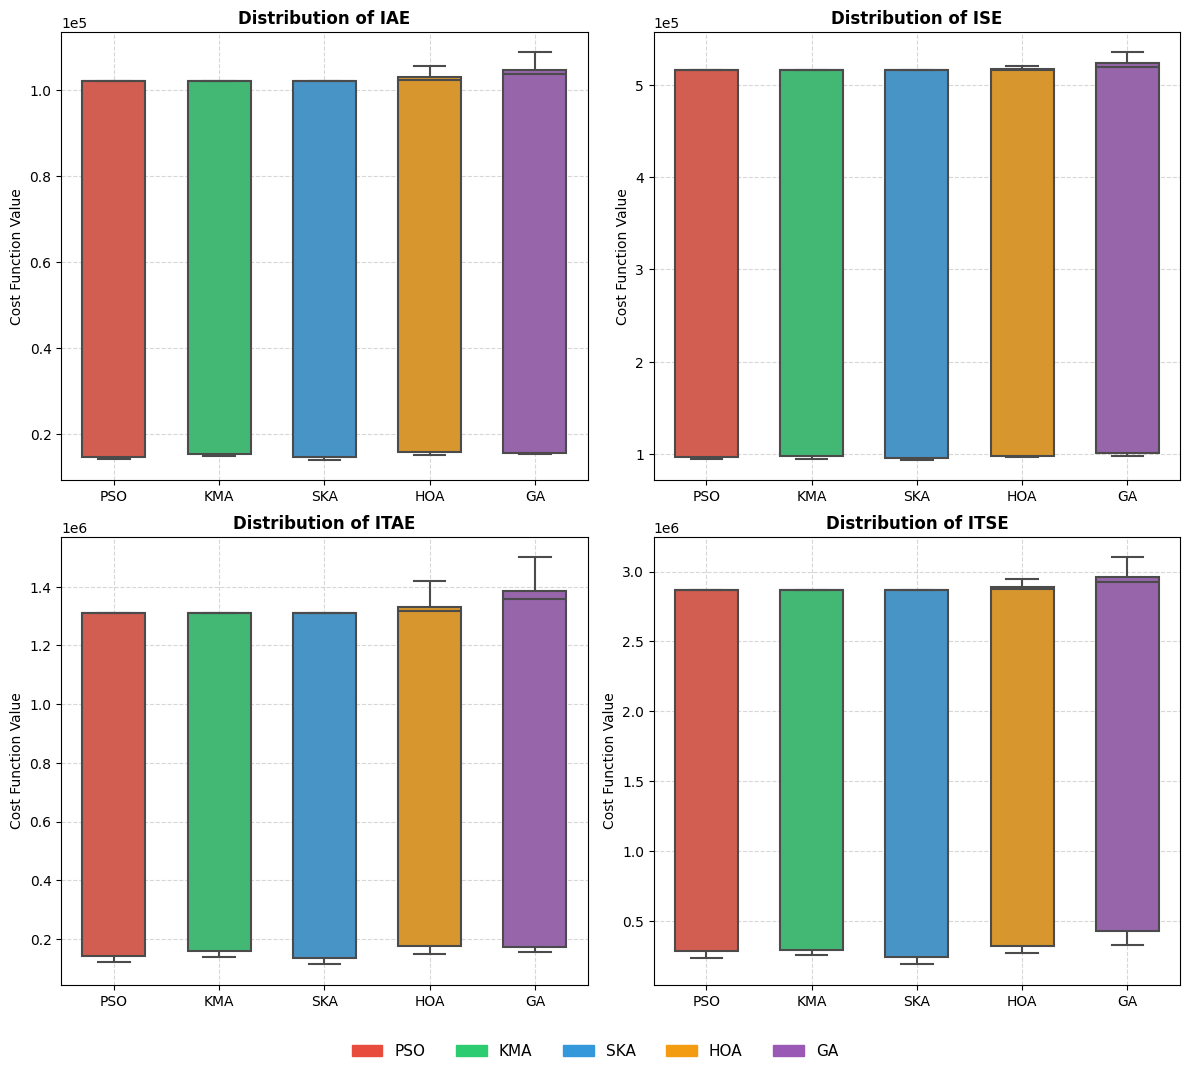

Gambar 'boxplot_comparison_consistent_colors.png' berhasil disimpan!


In [35]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import matplotlib.patches as mpatches # Diperlukan untuk Custom Legend

# 1. Load Data
# Pastikan file .pkl ada di direktori yang sama
if os.path.exists('all_best_fitnesses.pkl'):
    with open('all_best_fitnesses.pkl', 'rb') as f:
        data = pickle.load(f)
else:
    print("[ERROR] File 'all_best_fitnesses.pkl' tidak ditemukan.")
    # Stop execution or create dummy data here if needed
    data = {} 

# 2. Reformat Data untuk Plotting
plot_data = []
algos = ['pso', 'kma', 'ska', 'hoa', 'ga']
objs = ['iae', 'ise', 'itae', 'itse']

for obj in objs:
    for algo in algos:
        if algo in data.get(obj, {}):
            values = data[obj][algo]
            for v in values:
                plot_data.append({
                    'Objective': obj.upper(),
                    'Algorithm': algo.upper(),
                    'Fitness': v
                })

df_plot = pd.DataFrame(plot_data)

# 3. Setup Gambar (Grid 2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 11), sharex=False) # Tinggi ditambah sedikit untuk legend
axes = axes.flatten()

# --- UPDATE WARNA (Sesuai Convergence Plot) ---
# Skema warna ini SAMA PERSIS dengan plot konvergensi sebelumnya
my_pal = {
    "PSO": "#e74c3c",  # Merah
    "KMA": "#2ecc71",  # Hijau
    "SKA": "#3498db",  # Biru
    "HOA": "#f39c12",  # Orange (Sebelumnya abu-abu)
    "GA":  "#9b59b6"   # Ungu (Sebelumnya abu-abu)
}

for i, obj in enumerate(objs):
    ax = axes[i]
    # Filter data per objective
    subset = df_plot[df_plot['Objective'] == obj.upper()]
    
    if not subset.empty:
        # Gambar Boxplot
        sns.boxplot(
            x='Algorithm', 
            y='Fitness', 
            data=subset, 
            ax=ax, 
            palette=my_pal, 
            width=0.6, 
            linewidth=1.5,
            flierprops={"marker": "o", "markerfacecolor": "black", "markersize": 3}
        )
        
    # Judul & Label
    ax.set_title(f'Distribution of {obj.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Cost Function Value')
    
    # Format Scientific Notation
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    ax.grid(True, linestyle='--', alpha=0.5)

# 4. Tambahkan Legend Gabungan (Agar sesuai dengan Convergence Plot)
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in my_pal.items()]
fig.legend(
    handles=legend_patches,
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.02),
    ncol=5, 
    fontsize=11,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1) # Beri ruang untuk legend di bawah
plt.savefig('boxplot_comparison_consistent_colors.png', dpi=300)
plt.show()
print("Gambar 'boxplot_comparison_consistent_colors.png' berhasil disimpan!")

# LEGACY CODE! DO NOT USE!

In [36]:
# import pandas as pd

# obj = ["iae","ise","itae","itse"]
# algos = ["pso","kma","ska","hoa","ga"]

# rows = []
# for o in obj:
#     for a in algos:
#         for val in d[o][a]:
#             rows.append({
#                 "Objective": o.upper(),
#                 "Algorithm": a.upper(),
#                 "Fitness": val
#             })

# df_long = pd.DataFrame(rows)
# print(df_long.head())


In [37]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# sns.set(style="whitegrid")

# for o in df_long["Objective"].unique():
#     plt.figure(figsize=(8,5))
#     sns.boxplot(
#         data=df_long[df_long["Objective"] == o],
#         x="Algorithm",
#         y="Fitness"
#     )
#     plt.title(f"Boxplot of Fitness Values ({o})")
#     plt.ylabel("Objective Function Value")
#     plt.xlabel("Algorithm")
#     plt.tight_layout()
#     plt.savefig(f"boxplot_{o}.png", dpi=300)
#     plt.show()


# END OF LEGACY

# Stability Analysis using Interquartile Range (IQR)

In [38]:
import pickle
import numpy as np
from scipy import stats

# Load data rekap
with open('all_best_fitnesses.pkl', 'rb') as f:
    data = pickle.load(f)

objs = ['iae', 'ise', 'itae', 'itse']
# Algoritma yang mau dibandingkan
algos = ['pso', 'kma', 'ska', 'hoa', 'ga'] 

print(r"% --- TABLE: ROBUSTNESS METRICS (IQR & FLIGNER-KILLEEN) ---")
print(r"\begin{table}[ht]")
print(r"\centering")
print(r"\caption{Robustness Analysis: Interquartile Range (IQR) and Fligner-Killeen Test}")
print(r"\label{tab:robustness_stats}")
print(r"\resizebox{\textwidth}{!}{")
print(r"\begin{tabular}{l|cc|cc|cc|cc}")
print(r"\hline")
print(r"\textbf{Algo} & \multicolumn{2}{c|}{\textbf{CIAE}} & \multicolumn{2}{c|}{\textbf{CISE}} & \multicolumn{2}{c|}{\textbf{CITAE}} & \multicolumn{2}{c}{\textbf{CITSE}} \\")
print(r" & \textbf{IQR} & \textbf{Std Dev} & \textbf{IQR} & \textbf{Std Dev} & \textbf{IQR} & \textbf{Std Dev} & \textbf{IQR} & \textbf{Std Dev} \\ \hline")

# Bagian 1: Tampilkan IQR vs Std Dev
for algo in algos:
    row_str = f"{algo.upper()}"
    for obj in objs:
        vals = data[obj][algo]
        
        # Hitung IQR (Q3 - Q1)
        q75, q25 = np.percentile(vals, [75 ,25])
        iqr = q75 - q25
        std = np.std(vals)
        
        # Format angka (Scientific notation kalau besar)
        iqr_str = f"{iqr:.2e}" if iqr > 1000 else f"{iqr:.2f}"
        std_str = f"{std:.2e}" if std > 1000 else f"{std:.2f}"
        
        row_str += f" & {iqr_str} & {std_str}"
    print(row_str + r" \\")

print(r"\hline")

# Bagian 2: Fligner-Killeen Test (Global Stability Test)
print(r"\multicolumn{9}{c}{\textbf{Fligner-Killeen Test for Homogeneity of Variances}} \\ \hline")
print(r"\multicolumn{1}{l|}{\textbf{Metric}} & \multicolumn{2}{c|}{\textbf{Statistic}} & \multicolumn{2}{c|}{\textbf{$p$-value}} & \multicolumn{4}{l}{\textbf{Conclusion}} \\ \hline")

for obj in objs:
    # Kumpulkan data semua algo untuk diadu varians-nya
    samples = [data[obj][a] for a in algos]
    
    stat, p_val = stats.fligner(*samples)
    
    p_str = "$< 0.001$" if p_val < 0.001 else f"{p_val:.4f}"
    sig = "Significant Diff." if p_val < 0.05 else "Variances are Equal"
    
    print(f"{obj.upper()} & \multicolumn{{2}}{{c|}}{{{stat:.2f}}} & \multicolumn{{2}}{{c|}}{{{p_str}}} & \multicolumn{{4}}{{l}}{{{sig}}} \\\\")

print(r"\hline")
print(r"\end{tabular}")
print(r"}")
print(r"\end{table}")

% --- TABLE: ROBUSTNESS METRICS (IQR & FLIGNER-KILLEEN) ---
\begin{table}[ht]
\centering
\caption{Robustness Analysis: Interquartile Range (IQR) and Fligner-Killeen Test}
\label{tab:robustness_stats}
\resizebox{\textwidth}{!}{
\begin{tabular}{l|cc|cc|cc|cc}
\hline
\textbf{Algo} & \multicolumn{2}{c|}{\textbf{CIAE}} & \multicolumn{2}{c|}{\textbf{CISE}} & \multicolumn{2}{c|}{\textbf{CITAE}} & \multicolumn{2}{c}{\textbf{CITSE}} \\
 & \textbf{IQR} & \textbf{Std Dev} & \textbf{IQR} & \textbf{Std Dev} & \textbf{IQR} & \textbf{Std Dev} & \textbf{IQR} & \textbf{Std Dev} \\ \hline
PSO & 8.74e+04 & 4.13e+04 & 4.20e+05 & 1.98e+05 & 1.17e+06 & 5.54e+05 & 2.59e+06 & 1.23e+06 \\
KMA & 8.67e+04 & 4.10e+04 & 4.18e+05 & 1.97e+05 & 1.15e+06 & 5.46e+05 & 2.58e+06 & 1.22e+06 \\
SKA & 8.74e+04 & 4.13e+04 & 4.21e+05 & 1.98e+05 & 1.17e+06 & 5.56e+05 & 2.63e+06 & 1.25e+06 \\
HOA & 8.73e+04 & 4.13e+04 & 4.18e+05 & 1.97e+05 & 1.16e+06 & 5.55e+05 & 2.57e+06 & 1.22e+06 \\
GA & 8.91e+04 & 4.22e+04 & 4.22e+05 & 1.99

<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
C:\Users\valo\AppData\Local\Temp\ipykernel_28856\2231523246.py:57: SyntaxWarning: invalid escape sequence '\m'
  print(f"{obj.upper()} & \multicolumn{{2}}{{c|}}{{{stat:.2f}}} & \multicolumn{{2}}{{c|}}{{{p_str}}} & \multicolumn{{4}}{{l}}{{{sig}}} \\\\")
C:\Users\valo\AppData\Local\Temp\ipykernel_28856\2231523246.py:57: SyntaxWarning: invalid escape sequence '\m'
  print(f"{obj.upper()} & \multicolumn{{2}}{{c|}}{{{stat:.2f}}} & \multicolumn{{2}}{{c|}}{{{p_str}}} & \multicolumn{{4}}{{l}}{{{sig}}} \\\\")
C:\Users\valo\AppData\Local\Temp\ipykernel_28856\2231523246.py:57: SyntaxWarning: invalid escape sequence '\m'
  print(f"{obj.upper()} & \multicolumn{{2}}{{c|}}{{{stat:.2f}}} & \multicolum

# Full Best Fitness Plot

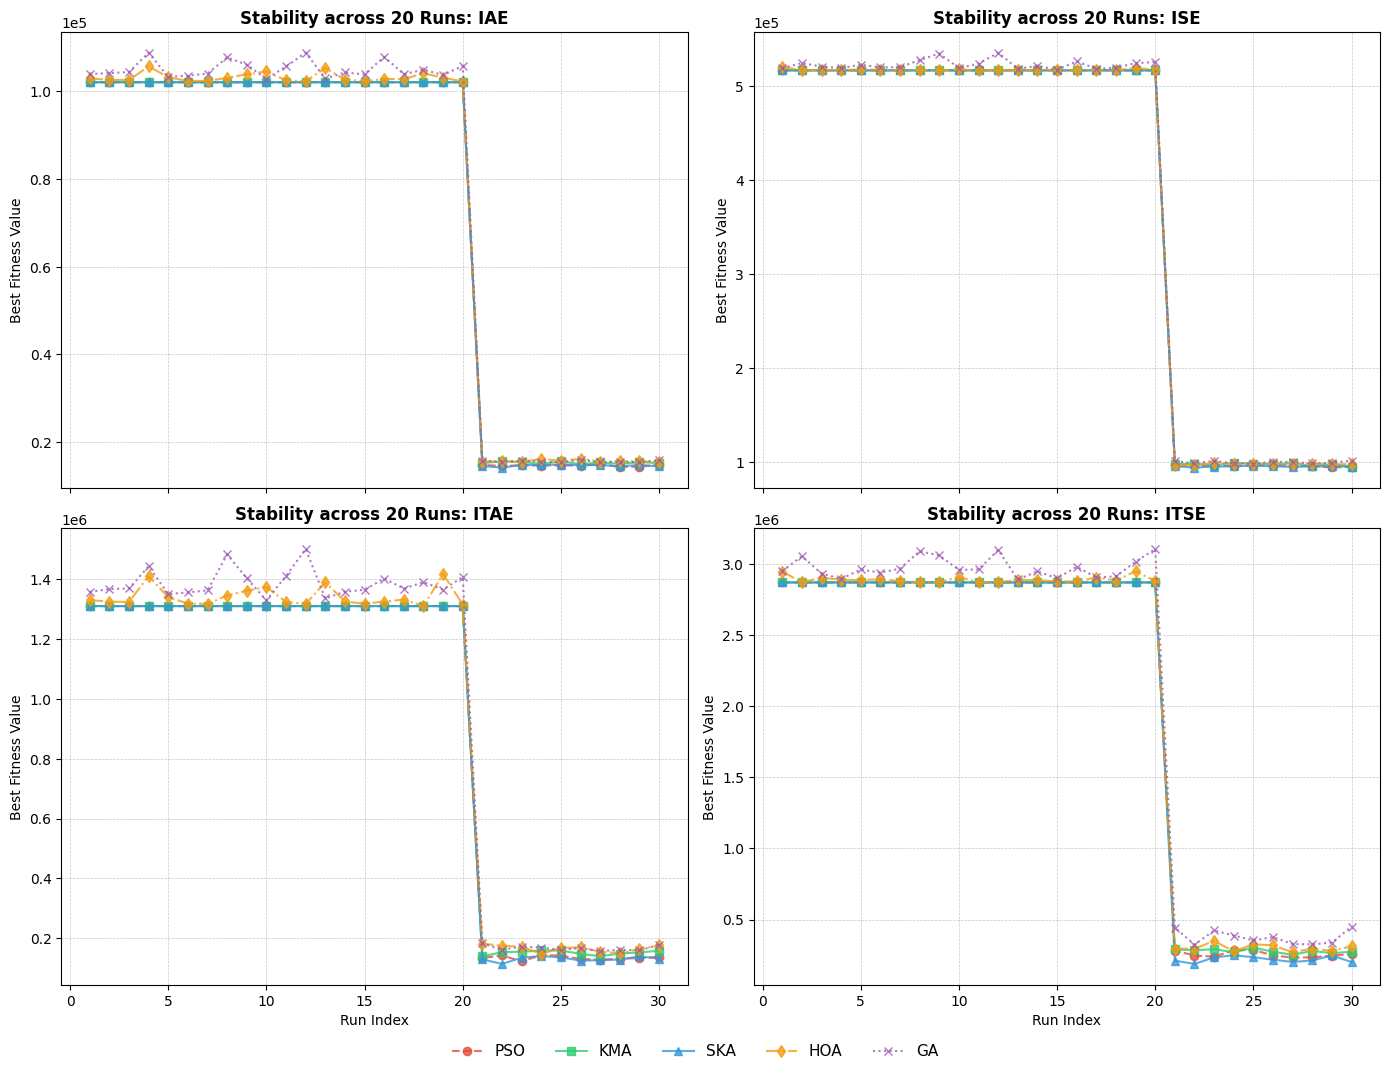

Grafik 'full_fitness_stability_plot_colored.png' berhasil dibuat!


In [39]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Load Data
file_path = 'all_best_fitnesses.pkl'

if os.path.exists(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
else:
    print("[ERROR] File pickle tidak ditemukan.")
    # Dummy data untuk testing jika file tidak ada
    data = {}

# 2. Setup Plot Configuration
objectives = ['iae', 'ise', 'itae', 'itse']
# algos = ['pso', 'kma', 'ska', 'hoa', 'ga'] # Urutan legend
algos = ['pso', 'kma', 'ska', 'hoa', 'ga']

# --- UPDATE WARNA & STYLE (Sesuai Convergence Plot) ---
# KMA (Hijau), SKA (Biru), PSO (Merah), HOA (Orange), GA (Ungu)
styles = {
    'pso': {'color': '#e74c3c', 'marker': 'o', 'label': 'PSO', 'ls': '--'},    # Red
    'kma': {'color': '#2ecc71', 'marker': 's', 'label': 'KMA', 'ls': '-'},     # Green
    'ska': {'color': '#3498db', 'marker': '^', 'label': 'SKA', 'ls': '-'},     # Blue
    'hoa': {'color': '#f39c12', 'marker': 'd', 'label': 'HOA', 'ls': '-.'},   # Orange
    'ga':  {'color': '#9b59b6', 'marker': 'x', 'label': 'GA',  'ls': ':'}      # Purple
}

# 3. Create Subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True) # Height ditambah dikit buat legend
axes = axes.flatten()

# List untuk menyimpan handle legend (biar rapi)
legend_handles = []
legend_labels = []

for i, obj in enumerate(objectives):
    ax = axes[i]
    
    # Ambil data per objective
    obj_data = data.get(obj, {})
    
    for algo in algos:
        if algo in obj_data:
            y_values = obj_data[algo]
            x_values = np.arange(1, len(y_values) + 1) # Run 1 sampai 20
            
            # Plot Line Chart
            line, = ax.plot(x_values, y_values, 
                    color=styles[algo]['color'], 
                    marker=styles[algo]['marker'],
                    linestyle=styles[algo]['ls'],
                    linewidth=1.5,
                    markersize=6,
                    label=styles[algo]['label'],
                    alpha=0.8)
            
            # Simpan handle untuk legend (hanya dari plot pertama biar tidak duplikat)
            if i == 0:
                legend_handles.append(line)
                legend_labels.append(styles[algo]['label'])

    # Kosmetik Grafik
    ax.set_title(f'Stability across 20 Runs: {obj.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Best Fitness Value')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # Mengatur Y-Axis ke Scientific Notation biar rapi
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# Label X-Axis untuk baris bawah saja
axes[2].set_xlabel('Run Index')
axes[3].set_xlabel('Run Index')

# 4. Tambahkan Legend Gabungan di Bawah
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.02),
    ncol=5, 
    fontsize=11,
    frameon=False
)

# Layout Adjustment
plt.tight_layout()
plt.subplots_adjust(bottom=0.1) # Beri ruang kosong di bawah untuk legend
plt.savefig('full_fitness_stability_plot_colored.png', dpi=300) # Simpan gambar
plt.show()

print("Grafik 'full_fitness_stability_plot_colored.png' berhasil dibuat!")

In [40]:
import pickle
import pandas as pd
import os

# 1. Load Data
with open('all_best_fitnesses.pkl', 'rb') as f:
    data = pickle.load(f)

objectives = ['iae', 'ise', 'itae', 'itse']
algos = ['pso', 'kma', 'ska', 'hoa', 'ga'] 

# 2. Loop per objective dan save ke CSV
for obj in objectives:
    # Siapkan dictionary untuk DataFrame
    # Kolom pertama: Run Index (1-20)
    csv_data = {'Run': list(range(1, 21))}
    
    obj_data = data.get(obj, {})
    
    for algo in algos:
        if algo in obj_data:
            # Masukkan data fitness per algo
            csv_data[algo.upper()] = obj_data[algo]
            
    # Buat DataFrame
    df = pd.DataFrame(csv_data)
    
    # Save ke CSV (tanpa index pandas)
    filename = f'stability_{obj}.csv'
    df.to_csv(filename, index=False)
    print(f"Berhasil menyimpan: {filename}")

print("\nSelesai! Sekarang upload 4 file CSV ini ke project LaTeX kamu.")

ValueError: All arrays must be of the same length

# Objective Function & Time Response Correlation
Although objective functions such as IAE, ISE, ITAE, and ITSE are widely used to guide controller optimization, their physical relevance to time-domain performance characteristics is often implicitly assumed. To explicitly investigate this relationship, correlation analysis was conducted between the objective function values and key time-domain response metrics, including rise time, overshoot, settling time, and steady-state error.

Since the analyzed data do not necessarily follow a normal distribution and may exhibit non-linear monotonic relationships, Spearman’s rank correlation coefficient was employed. This analysis aims to reveal how effectively each objective function reflects the underlying dynamic behavior of the ACC system, thereby providing insight into their suitability for safety- and efficiency-oriented controller design.

## Time Response Preparation (LEGACY! DONT USE IT!)

In [ ]:
# from benchmarks.sisken_prastiyanto import lean_simulate_system
# from core.utils import iae, ise, itae, itse

# import ast
# import pandas as pd

# objectives = {
#     "iae": iae,
#     "ise": ise,
#     "itae": itae,
#     "itse": itse,
# }

# with open("all_best_solutions.txt") as f:
#     best_params = ast.literal_eval(f.read())

# import numpy as np

# def extract_metrics(history):
#     time = np.array(history["time"])
#     e_d  = np.array(history["err"])      # spacing error
#     v_e  = np.array(history["v_ego"])
#     v_l  = np.array(history["v_lead"])
#     a_e  = np.array(history["a_ego"])

#     metrics = {}

#     # SAFETY
#     metrics["min_spacing_error"] = np.min(e_d)
#     metrics["unsafe_time"] = np.sum(e_d < 0) * (time[1] - time[0])
#     metrics["peak_abs_error"] = np.max(np.abs(e_d))

#     # TRACKING
#     metrics["rms_spacing_error"] = np.sqrt(np.mean(e_d**2))
#     metrics["rms_speed_error"] = np.sqrt(np.mean((v_l - v_e)**2))

#     # COMFORT
#     metrics["max_acc"] = np.max(np.abs(a_e))
#     metrics["rms_acc"] = np.sqrt(np.mean(a_e**2))

#     return metrics


# results = []

# for obj_name, algo_dict in best_params.items():
#     obj_fun = objectives[obj_name]   # mapping iae → function

#     for algo, param_list in algo_dict.items():
#         for run_id, params in enumerate(param_list):

#             fitness, history = lean_simulate_system(
#                 params, obj_fun, return_history=True
#             )

#             metrics = extract_metrics(history)

#             row = {
#                 "objective": obj_name.upper(),
#                 "algorithm": algo.upper(),
#                 "run": run_id,
#                 "fitness": fitness
#             }
#             row.update(metrics)
#             results.append(row)

# df = pd.DataFrame(results)
# df.to_csv("acc_full_evaluation.csv", index=False)


In [ ]:
# import pickle

# file_path = 'c:/Users/krnwn/Downloads/Telegram Desktop/concurrent/ACC-Optimization-main-concurrent/checkpoint_jobs/acc_run_19_pso_itse.pkl' # Replace with your file's path

# # Open the file in binary mode ('rb') and load the data
# try:
#     with open(file_path, 'rb') as file:
#         data = pickle.load(file)
    
#     # Print the loaded object
#     print(data)

# except FileNotFoundError:
#     print(f"Error: The file '{file_path}' was not found.")
# except Exception as e:
#     print(f"An error occurred: {e}")


# END OF LEGACY

# Time Response Cruise Control Analysis

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from benchmarks.sisken_prastiyanto import error_synthesizer
from core.physics import VehiclePhysics
from core.utils import iae, ise, itae, itse
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import os


def step_response_metrics(time, y, ref, y0=None, steady_window=2.0, tol=0.02, rise_frac=(0.1, 0.9)):
    """
    Compute step-response metrics for a step-to-constant reference.
    - time: array (seconds)
    - y: measured signal (e.g., v_ego)
    - ref: target setpoint (e.g., 25 m/s)
    - y0: initial value (if None uses y[0])
    - steady_window: seconds from the end used to estimate steady-state value (mean of last window)
    - tol: settling band ratio, e.g., 0.02 = 2%
    - rise_frac: (low, high) fractions of step amplitude (default 10%-90%)

    Returns dict with:
      y0, y_ss, ss_error,
      peak_value, peak_time,
      overshoot, overshoot_pct,
      rise_time, t10, t90,
      settling_time
    """
    t = np.asarray(time, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(t) == 0:
        raise ValueError("Empty time series.")

    if y0 is None:
        y0 = float(y[0])

    # steady-state estimate from last steady_window seconds (mean)
    t_end = float(t[-1])
    if steady_window is not None and steady_window > 0:
        mask = t >= (t_end - steady_window)
        y_ss = float(np.mean(y[mask])) if np.any(mask) else float(y[-1])
    else:
        y_ss = float(y[-1])

    ss_error = float(ref - y_ss)

    # Determine step direction by comparing ref vs y0
    rising = ref >= y0
    direction = "rising" if rising else "falling"

    # Peak / extreme
    if rising:
        peak_idx = int(np.argmax(y))
        peak_value = float(y[peak_idx])
        peak_time = float(t[peak_idx])
        overshoot = max(0.0, peak_value - ref)
    else:
        peak_idx = int(np.argmin(y))
        peak_value = float(y[peak_idx])
        peak_time = float(t[peak_idx])
        overshoot = max(0.0, ref - peak_value)

    step_amp = abs(ref - y0)
    overshoot_pct = float(100.0 * overshoot / step_amp) if step_amp > 0 else 0.0

    # Rise time 10%-90% of step amplitude (based on y0 -> ref)
    low_f, high_f = rise_frac
    low_level = y0 + (ref - y0) * low_f
    high_level = y0 + (ref - y0) * high_f

    t10 = _first_crossing_time(t, y, low_level, direction=direction)
    t90 = _first_crossing_time(t, y, high_level, direction=direction)
    rise_time = (t90 - t10) if (t10 is not None and t90 is not None and t90 >= t10) else None

    # Settling time relative to ref (common in control)
    ts = settling_time(t, y, y_final=ref, tol=tol, start_time=t10)

    return {
        "y0": float(y0),
        "y_ss": float(y_ss),
        "steady_state_error": ss_error,

        "peak_value": peak_value,
        "peak_time": peak_time,

        "overshoot": float(overshoot),
        "overshoot_pct": float(overshoot_pct),

        "t10": t10,
        "t90": t90,
        "rise_time": float(rise_time) if rise_time is not None else None,

        "settling_time": ts,
        "ref": float(ref),
        "tol": float(tol),
    }


# --- (Bagian params dan fungsi lainnya sama seperti sebelumnya) ---
params = {
  "iae": {
    "kma": [10.0, 0.42077545, -10.0],
    "pso": [10.0, 0.42077545, -10.0],
    "ska": [10.0, 0.42077545, -10.0],
    "hoa": [9.88721521, 0.47805548, -9.45343288],
    "ga":  [8.80156662, 0.66311295, -9.83746091]
  },
  "ise": {
    "kma": [10.0, 3.59572741, -10.0],
    "pso": [10.0, 3.59572492, -10.0],
    "ska": [10.0, 3.59572753, -10.0],
    "hoa": [10.0, 3.58054097, -10.0],
    "ga":  [9.9654988, 1.94943357, -5.56616292]
  },
  "itae": {
    "kma": [10.0, 0.42208615, -10.0],
    "pso": [10.0, 0.42208615, -10.0],
    "ska": [10.0, 0.42208638, -10.0],
    "hoa": [10.0, 0.41665973, -10.0],
    "ga":  [8.80156662, 0.66311295, -9.83746091]
  },
  "itse": {
    "kma": [10.0, 4.02152747, -10.0],
    "pso": [10.0, 4.02152946, -10.0],
    "ska": [10.0, 4.02153039, -10.0],
    "hoa": [10.0, 3.80840027, -9.67951174],
    "ga":  [9.18682319, 3.42917675, -8.45620702]
  }
}

SCENARIOS = [
    {"theta_angle": 0,  "vehicle_mass": 1500, "rolling_resistance": 0.06},
    {"theta_angle": 0,  "vehicle_mass": 1500*1.1, "rolling_resistance": 0.06},
    {"theta_angle": 0,  "vehicle_mass": 1500*0.9, "rolling_resistance": 0.06},
    {"theta_angle": 0,  "vehicle_mass": 1500, "rolling_resistance": 0.06*1.2},

    {"theta_angle": 10, "vehicle_mass": 1500, "rolling_resistance": 0.06},
    {"theta_angle": 10, "vehicle_mass": 1500*1.1, "rolling_resistance": 0.06},
    {"theta_angle": 10, "vehicle_mass": 1500*0.9, "rolling_resistance": 0.06},
    {"theta_angle": 10, "vehicle_mass": 1500, "rolling_resistance": 0.06*1.2},

    {"theta_angle": -10, "vehicle_mass": 1500, "rolling_resistance": 0.06},
    {"theta_angle": -10, "vehicle_mass": 1500*1.1, "rolling_resistance": 0.06},
    {"theta_angle": -10, "vehicle_mass": 1500*0.9, "rolling_resistance": 0.06},
    {"theta_angle": -10, "vehicle_mass": 1500, "rolling_resistance": 0.06*1.2},
]

objectives = {"iae": iae, "ise": ise, "itae": itae, "itse": itse}

def compute_jerk(a_ego, dt):
    a = np.array(a_ego)
    jerk = np.diff(a) / dt
    return np.concatenate([[0], jerk])  # align length

def compute_ttc(d_actual, v_ego, v_lead, eps=1e-9):
    """
    TTC definition (classic):
    TTC = d / (v_ego - v_lead) when v_ego > v_lead and d > 0
    otherwise TTC = inf
    """
    if d_actual <= 0:
        return 0.0  # already collided / overlap (or negative distance)
    dv = v_ego - v_lead
    if dv <= eps:
        return math.inf
    return d_actual / dv


import numpy as np

def _interp_crossing_time(t, y, level, idx):
    """
    Linear interpolation to estimate crossing time between idx-1 and idx
    where y crosses 'level'. Assumes (y[idx-1]-level) and (y[idx]-level) have opposite signs.
    """
    t0, t1 = t[idx - 1], t[idx]
    y0, y1 = y[idx - 1], y[idx]
    if y1 == y0:
        return float(t1)
    alpha = (level - y0) / (y1 - y0)
    return float(t0 + alpha * (t1 - t0))

def _first_crossing_time(t, y, level, direction="auto"):
    """
    Returns the first time y crosses 'level' (with interpolation).
    direction:
      - "rising": crossing from below to above
      - "falling": crossing from above to below
      - "auto": decide from start/end trend
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(t) < 2:
        return None

    if direction == "auto":
        direction = "rising" if (y[-1] >= y[0]) else "falling"

    if direction == "rising":
        cond = (y[:-1] < level) & (y[1:] >= level)
    else:
        cond = (y[:-1] > level) & (y[1:] <= level)

    idxs = np.where(cond)[0]
    if idxs.size == 0:
        return None

    i = int(idxs[0] + 1)
    return _interp_crossing_time(t, y, level, i)

def settling_time(t, y, y_final, tol=0.02, start_time=None):
    """
    Settling time: earliest time after which y stays within +/- tol*|y_final|
    (or absolute band if y_final == 0) for the remainder.
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(t) == 0:
        return None

    if start_time is not None:
        mask = t >= start_time
        t2, y2 = t[mask], y[mask]
    else:
        t2, y2 = t, y

    if len(t2) == 0:
        return None

    band = tol * abs(y_final) if y_final != 0 else tol
    outside = np.abs(y2 - y_final) > band

    if not np.any(outside):
        return float(t2[0])  # already settled at start

    last_outside_idx = int(np.where(outside)[0][-1])
    if last_outside_idx == len(t2) - 1:
        return None  # never settles within horizon
    return float(t2[last_outside_idx + 1])

def plot_velocity_compare(
    obj_name,
    histories_by_algo,
    metrics_by_algo,
    outdir="figures/step_response",
    ref=25.0,
    show_metrics_in_legend=True,
    # --- MANUAL ZOOM CONFIG (WORKAROUND) ---
    zoom_xlim=(0.85, 1.10), 
    zoom_ylim=(24.90, 25.02),
    inset_size=("55%", "50%"),
    inset_loc="center right"
):
    os.makedirs(outdir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Style Dictionary (Warna konsisten)
    styles = {
        'pso': {'color': '#e74c3c', 'ls': '-', 'lw': 2.0, 'label': 'PSO'},   # Red
        'kma': {'color': '#2ecc71', 'ls': '-',  'lw': 2.0, 'label': 'KMA'},    # Green
        'ska': {'color': '#3498db', 'ls': '-',  'lw': 2.0, 'label': 'SKA'},    # Blue
        'hoa': {'color': '#f39c12', 'ls': '-.', 'lw': 2.0, 'label': 'HOA'},    # Orange
        'ga' : {'color': '#9b59b6', 'ls': '-',  'lw': 2.0, 'label': 'GA'},     # Purple
    }

    # ============ MAIN PLOT ============
    for algo, hist in histories_by_algo.items():
        t = np.asarray(hist["time"])
        v = np.asarray(hist["v_ego"])

        # --- LOGIC LABEL LEGEND BARU ---
        if show_metrics_in_legend:
            m = metrics_by_algo[algo]
            mp = m.get("overshoot", None)
            tr = m.get("rise_time", None)
            ts = m.get("settling_time", None)
            
            # Hitung Steady State Error (Ess) secara manual dari data terakhir
            final_v = v[-1]
            ess = abs(ref - final_v)

            mp_pct = (mp * 100.0) if (mp is not None and np.isfinite(mp)) else None
            
            # Format Label
            label = f"{algo.upper()}"
            # if mp_pct is not None: label += f" | Mp={mp_pct:.2f}%"
            # if tr is not None and np.isfinite(tr): label += f" | tr={tr:.2f}s"
            # if ts is not None and np.isfinite(ts): label += f" | ts={ts:.2f}s"
            
            # Tampilkan Ess (4 desimal agar kelihatan bedanya)
            # label += f" | Ess={ess:.4f}" 
        else:
            label = algo.upper()

        algo_key = algo.lower()
        st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 1.8, 'label': algo.upper()})
        ax.plot(t, v, linewidth=st['lw'], linestyle=st['ls'], color=st['color'], label=label)

    ax.axhline(ref, linestyle="--", linewidth=1.5, label=f"Reference = {ref:.1f} m/s")
    ax.set_title(f"Speed Step Response Comparison — Objective: {obj_name.upper()}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Ego speed (m/s)")
    ax.grid(True)

    # Legend ditaruh di kiri bawah agak naik dikit
    leg = ax.legend(
        loc="lower left",
        bbox_to_anchor=(0.1, 0.08), # Naikkan sedikit (0.02 -> 0.08) biar gak kena sumbu X
        fontsize=8,
        frameon=True,
        framealpha=0.9
    )
    leg.set_zorder(30)

    # # ============ INSET PLOT (MANUAL) ============
    axins = inset_axes(ax, width=inset_size[0], height=inset_size[1],
                        loc=inset_loc, borderpad=1.0) 
    
    for algo, hist in histories_by_algo.items():
        algo_key = algo.lower()
        st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 2.0})
        axins.plot(hist["time"], hist["v_ego"], linewidth=st['lw'], linestyle=st['ls'], color=st['color']) 
    
    axins.axhline(ref, linestyle="--", linewidth=1.5, color='#1f77b4', alpha=0.9)
    
    # --- MANUAL LIMITS ---
    axins.set_xlim(*zoom_xlim)
    axins.set_ylim(*zoom_ylim)
    
    axins.grid(True)
    axins.tick_params(axis='both', which='major', labelsize=8)

    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5", alpha=0.7)

    plt.tight_layout()
    outpath = os.path.join(outdir, f"speed_compare_{obj_name.lower()}_zoom_manual.png")
    plt.savefig(outpath, dpi=250)
    plt.show()
    plt.close(fig)
    

def lean_simulate_system(params, obj_fun, return_history=False, 
                         sim_time=60, theta_angle=0, vehicle_mass=1500, 
                         rolling_resistance=0.06, v_ref_init=25):
    """
    obj_fun is now a FUNCTION, not a string.
    It must accept (err, time) or (err) depending on the metric.
    """
    physics = VehiclePhysics(theta=theta_angle, M=vehicle_mass, Croll=rolling_resistance)

    verr_gain, vx_gain, xerr_gain = params
    theta = 0
    vset = v_ref_init or 25.0
    xego, vego, aego = 0, 22, 0
    xlead, vlead, alead = 60, 22, 0
    ddef, Tg = 20, 1.2
    Ts = 1 / 60
    obj_val = 0
    simulation_steps = int(sim_time / Ts)

    history = {
        "time": [],
        "v_ego": [],
        "v_ref": [],
        "u": [],
    }

    for i in range(simulation_steps):
        t = i * Ts

        # Compute errors
        dactual = xlead - xego
        dsafe   = ddef + Tg * vego

        vrel    = vlead - vego
        derr    = dsafe - dactual
        verr    = vset - vego

        # Controller
        u_v = verr_gain * verr
        # u_x = vrel * vx_gain + xerr_gain * derr

        # LOGIKA SWITCHING YANG LEBIH LOGIS
        u = u_v

        # Update ego car
        vego, aego, Ft = physics.step(vego, u, Ts)
        xego += vego * Ts

        c_nrg   = max(0, Ft)
        err     = error_synthesizer(derr, verr, 0, t, obj_fun)
        obj_val += err

        history["time"].append(t)
        history["v_ego"].append(vego)
        history["v_ref"].append(vset)
        history["u"].append(u)
            # history["v_lead"].append(vlead)
            # history["x_ego"].append(xego)
            # history["x_lead"].append(xlead)
            # history["car_force"].append(Ft)
            # history["dist"].append(dactual)
            # history["a_ego"].append(aego)
            # history["err"].append(err)

    return history

def run_all(params, objectives, ref=25.0, steady_window=2.0, tol=0.001, steady_state_plot=False):
    """
    tol=0.02 means 2% settling band (lebih standar).
    Kamu sebelumnya pakai 0.0002 (0.02%) itu super ketat dan sering bikin ts jadi aneh/None.
    """
    all_histories = {}
    all_metrics = {}

    for obj_name, algo_params in params.items():
        histories_by_algo = {}
        metrics_by_algo = {}

        for algo_name, param_vec in algo_params.items():
            from core.utils import cappiello_iae
            hist = simulate_cruise_response(param_vec, v_ref_init=ref, return_history=True) if False else lean_simulate_system(param_vec, cappiello_iae, v_ref_init=ref)
            histories_by_algo[algo_name] = hist

            metrics_by_algo[algo_name] = step_response_metrics(
                time=hist["time"],
                y=hist["v_ego"],
                ref=ref,
                steady_window=steady_window,
                tol=tol,
            )

        all_histories[obj_name] = histories_by_algo
        all_metrics[obj_name] = metrics_by_algo

        # One plot per objective with all algos
        plot_velocity_compare(obj_name, histories_by_algo, metrics_by_algo, ref=ref)

        # Optional: print a compact summary (sorted by settling time)
        rows = []
        for algo, m in metrics_by_algo.items():
            rows.append((algo.upper(), m.get("rise_time"), m.get("peak_time"), m.get("settling_time"), m.get("overshoot"), m.get("steady_state_error")))
        rows.sort(key=lambda x: (np.inf if x[3] is None else x[3]))

        print(f"\n=== Objective {obj_name.upper()} — time-domain summary (sorted by ts) ===")
        for r in rows:
            algo, tr, tp, ts, mp, ess = r
            mp_pct = (mp * 100.0) if mp is not None else None
            print(f"{algo:>4s} | tr={tr:.3f} | tp={tp:.3f} | ts={ts} | Mp%={mp_pct} | ess={ess}")

    return all_histories, all_metrics

run_all(params, objectives, ref=25.0, steady_window=2.0, tol=0.002, steady_state_plot=False)

# TTC-based Distance Control

In [ ]:
from core.physics import VehiclePhysics
from core.utils import sin_angle, iae, ise, itae, itse, cappiello_iae, cappiello_ise, cappiello_itae, cappiello_itse
from benchmarks.sisken_prastiyanto import lean_simulate_system_noisy
import math
import numpy as np
import matplotlib.pyplot as plt
import os

# --- (Bagian params dan fungsi lainnya sama seperti sebelumnya) ---
# NEW VARS
params = {
  "iae": {
    "kma": [10.0, 0.42077545, -10.0],
    "pso": [10.0, 0.42077545, -10.0],
    "ska": [10.0, 0.42077545, -10.0],
    "hoa": [9.88721521, 0.47805548, -9.45343288],
    "ga":  [8.80156662, 0.66311295, -9.83746091]
  },
  "ise": {
    "kma": [10.0, 3.59572741, -10.0],
    "pso": [10.0, 3.59572492, -10.0],
    "ska": [10.0, 3.59572753, -10.0],
    "hoa": [10.0, 3.58054097, -10.0],
    "ga":  [9.9654988, 1.94943357, -5.56616292]
  },
  "itae": {
    "kma": [10.0, 0.42208615, -10.0],
    "pso": [10.0, 0.42208615, -10.0],
    "ska": [10.0, 0.42208638, -10.0],
    "hoa": [10.0, 0.41665973, -10.0],
    "ga":  [8.80156662, 0.66311295, -9.83746091]
  },
  "itse": {
    "kma": [10.0, 4.02152747, -10.0],
    "pso": [10.0, 4.02152946, -10.0],
    "ska": [10.0, 4.02153039, -10.0],
    "hoa": [10.0, 3.80840027, -9.67951174],
    "ga":  [9.18682319, 3.42917675, -8.45620702]
  }
}


# OLD VARS

# params = {
#     "iae": {
#         "pso": [10.,          1.33986797, -0.48004842],
#         "kma": [10.,          1.36024896, -0.48727716],
#         "ska": [ 9.99986335,  1.34370536, -0.48127908],
#         "hoa": [ 8.31072198,  1.53944884, -0.57676628],
#         "ga":  [ 9.38098806,  6.21021944, -2.0370074 ]
#     },
#     "ise": {
#         "pso": [10.,          1.13546875, -0.44516747],
#         "kma": [10.,          1.14400827, -0.44745077],
#         "ska": [ 9.99996452,  1.13691399, -0.44559222],
#         "hoa": [ 8.57070359,  1.43015264, -0.54679418],
#         "ga":  [ 8.0169171,   7.97738153, -2.86312768]
#     },
#     "itae": {
#         "pso": [10.,          1.86852474, -0.58387247],
#         "kma": [10.,          1.90155071, -0.59267257],
#         "ska": [10.,          1.86898205, -0.58398794],
#         "hoa": [ 9.44084719,  3.77306862, -1.05930192],
#         "ga":  [ 9.25457014,  8.45332821, -2.27809434],
#     },
#     "itse": {
#         "pso": [10.,          1.28359219, -0.45907102],
#         "kma": [10.,          1.31754822, -0.4698925 ],
#         "ska": [ 9.9999867,   1.27994975, -0.45784665],
#         "hoa": [ 9.36804712,  1.33431976, -0.49507252],
#         "ga":  [ 5.88940832,  1.71232971, -0.60364586]
#     }
# }

objectives = {"iae": iae, "ise": ise, "itae": itae, "itse": itse, 
              "ciae": cappiello_iae, "cise": cappiello_ise, "citae": cappiello_itae, "citse": cappiello_itse}

def compute_ttc(d_actual, v_ego, v_lead, eps=1e-9):
    if d_actual <= 0:
        return 0.0
    dv = v_ego - v_lead
    if dv <= eps:
        return math.inf
    return d_actual / dv


import math
from core.utils import sin_angle
from benchmarks.sisken_prastiyanto import error_synthesizer

def lean_simulate_system(params, obj_fun, return_history=False, 
                         sim_time=60, theta_angle=0, vehicle_mass=1500, 
                         rolling_resistance=0.06, ttc_threshold=3.0, seed=420):
    """
    obj_fun is now a FUNCTION, not a string.
    It must accept (err, time) or (err) depending on the metric.
    """
    # np.random.seed(seed)
    physics = VehiclePhysics(theta=theta_angle, M=vehicle_mass, Croll=rolling_resistance)

    Kve, Kvrel, Kxe = params
    theta = 0
    vset = 25
    xego, vego, aego = 0, 22, 0
    xlead, vlead, alead = 60, 22, 0

    ddef, Tg = 20, 1.2
    Ts = 1 / 60
    simulation_steps = int(sim_time / Ts)

    history = {
        "time": [], "v_ego": [], "x_ego": [], 
        "a_ego": [], "v_lead": [], "x_lead": [],
        "a_lead": [], "dist_true": [], 
        "dist_reading": [], "mode": [], "cost_instant": [],
        "time": [], "ttc": [], "d_safe": [],
        "tet": None, "tit": None, "ttc_min": None,
    }

    obj_val = 0.0
    TET = 0.0
    TIT = 0.0
    ttc_min = math.inf


    import numpy as np

    # --- Inisialisasi State Pengemudi (Di LUAR Loop) ---
    lead_action = 0      # 0: Cruising, 1: Akselerasi, -1: Deselerasi
    action_timer = 0     # Penghitung waktu untuk menahan aksi
    vlead_max = 25.0     # Maksimum speed lead car (misal 25 m/s = 90 km/h)


    for i in range(simulation_steps):
        t = i * Ts

        # Compute errors
        dactual = xlead - xego
        dsafe   = ddef + Tg * vego

        vrel    = vlead - vego
        derr    = dsafe - dactual
        verr    = vset - vego

        # Controller
        u_v = Kve * verr
        u_x = vrel * Kvrel + Kxe * derr
    
        # LOGIKA SWITCHING YANG LEBIH LOGIS
        u = min(u_x, u_v)

        # Update ego car
        vego, aego, Ft = physics.step(vego, u, Ts)
        xego += vego * Ts

        # Update lead car
        theta = (theta + 30 * Ts) % 360
        alead = sin_angle(theta)
        vlead += alead * Ts
        xlead += vlead * Ts

        c_nrg   = max(0, Ft)
        err     = 0
        obj_val += err

    
        ttc = compute_ttc(dactual, vego, vlead)
        if ttc < ttc_min:
            ttc_min = ttc

        if ttc < ttc_threshold:
            TET += Ts
            TIT += (ttc_threshold - ttc) * Ts

        if return_history:
            history["time"].append(t)
            history["a_ego"].append(aego)
            history["a_lead"].append(alead)
            history["v_ego"].append(vego)
            history["v_lead"].append(vlead)
            history["x_ego"].append(xego)
            history["x_lead"].append(xlead)
            history["dist_true"].append(dactual)
            history["d_safe"].append(dsafe)
            history["cost_instant"].append(err)
            history["ttc"].append(ttc)

        history["tet"] = TET
        history["tit"] = TIT
        history["ttc_min"] = ttc_min if ttc_min != math.inf else None
    return [obj_val, history] if return_history else obj_val



def plot_ttc_compare_for_objective(obj_name, histories_by_algo, outpath,
                                   ttc_threshold=3.0, ttc_max_plot=None):
    """
    Modified: No metrics in title. Cleaner plot.
    """
    any_hist = next(iter(histories_by_algo.values()))
    time = np.array(any_hist["time"])

    plt.figure(figsize=(12, 6)) # Adjusted size slightly for paper fit
    
    # Style Dictionary (Warna konsisten)
    styles = {
        'pso': {'color': '#e74c3c', 'ls': '-', 'lw': 2.0},  # Red
        'kma': {'color': '#2ecc71', 'ls': '-',  'lw': 2.0},   # Green
        'ska': {'color': '#3498db', 'ls': '-',  'lw': 2.0},   # Blue
        'hoa': {'color': '#f39c12', 'ls': '-.', 'lw': 2.0},   # Orange
        'ga' : {'color': '#9b59b6', 'ls': '-',  'lw': 2.0},   # Purple
    }

    # Plot each algorithm
    for algo, hist in histories_by_algo.items():
        ttc = np.array(hist["ttc"], dtype=float)

        if ttc_max_plot is not None:
            ttc = np.where(np.isfinite(ttc), np.minimum(ttc, ttc_max_plot), ttc_max_plot)

        algo_key = algo.lower()
        st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 1.5})
        plt.plot(time, ttc, linewidth=st['lw'], linestyle=st['ls'], color=st['color'], label=algo.upper())

    # Critical Threshold Line (Red & Dashed for emphasis)
    plt.axhline(ttc_threshold, color='red', linestyle="--", linewidth=1.5, 
                label=f"Critical Threshold ({ttc_threshold}s)")

    # Judul Bersih
    plt.title(f"Time-to-Collision (TTC) Comparison — Objective: {obj_name.upper()}")
    plt.xlabel("Time (s)")
    plt.ylabel("TTC (s)")
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    
    # Legend placement optimization
    plt.legend(loc="upper right", framealpha=0.9)

    plt.tight_layout()
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    plt.savefig(outpath, dpi=300) # High DPI for paper
    plt.close()

# --- FUNGSI PLOT 2: MOTION PROFILE (Baru) ---
def plot_motion_profiles(obj_name, histories_by_algo, outpath):
    """
    Plot 3 Subplots: 
    1. Relative Distance (Headway)
    2. Velocity Profile
    3. Acceleration Profile
    """
    any_hist = next(iter(histories_by_algo.values()))
    time = np.array(any_hist["time"])
    
    # Ambil data Lead Vehicle (Cukup ambil dari salah satu algo, karena sama semua)
    v_lead = np.array(any_hist["v_lead"])
    a_lead = np.array(any_hist["a_lead"])

    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    
    # Styles Dictionary (Sama dengan TTC)
    styles = {
        'pso': {'color': '#e74c3c', 'ls': '-', 'lw': 1.5, 'zorder': 3},  # Red
        'kma': {'color': '#2ecc71', 'ls': '-', 'lw': 1.5, 'zorder': 5},   # Green
        'ska': {'color': '#3498db', 'ls': '-', 'lw': 1.5, 'zorder': 4},   # Blue
        'hoa': {'color': '#f39c12', 'ls': '-.', 'lw': 1.5, 'zorder': 2},  # Orange
        'ga' : {'color': '#9b59b6', 'ls': '-', 'lw': 1.5, 'zorder': 1}    # Purple
    }
    # --- SUBPLOT 1: RELATIVE DISTANCE & SAFE DISTANCE ---
    ax = axes[0]
    for algo, hist in histories_by_algo.items():
        algo_key = algo.lower()
        st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 1})
        lbl = algo.upper()
        
        dist = np.array(hist["dist_true"])
        dsafe = np.array(hist["d_safe"]) 
        
        # Plot Actual Distance (Solid Line with Algo Color)
        ax.plot(time, dist, color=st['color'], ls=st['ls'], lw=st['lw'], label=lbl, zorder=st['zorder'])
        
        # Plot Safe Distance (BLACK DASHED LINE - Like Lead Vehicle)
        # alpha=0.4 agar tidak terlalu dominan jika menumpuk
        ax.plot(time, dsafe, color='black', ls='--', lw=1.2, alpha=0.4, zorder=1)
    
    # Legend Entry Khusus untuk Safe Distance (Black Dashed)
    ax.plot([], [], color='black', ls='--', label='Safe Dist ($d_{safe}$)')

    ax.set_ylabel("Distance (m)")
    ax.set_title(f"Motion Profile Analysis — {obj_name.upper()}\n(a) Inter-vehicle Distance vs Safe Distance")
    ax.grid(True, linestyle='--', alpha=0.6)
    # Menampilkan legend (Kolom ditambah agar muat)
    ax.legend(loc="upper left", fontsize='small', ncol=3)


    # --- SUBPLOT 2: VELOCITY ---
    ax = axes[1]
    # Plot Lead Velocity Reference
    ax.plot(time, v_lead, 'k--', linewidth=2.0, label="Lead Vehicle", alpha=0.7)
    
    for algo, hist in histories_by_algo.items():
        algo_key = algo.lower()
        st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 1})
        vel = np.array(hist["v_ego"])
        ax.plot(time, vel, color=st['color'], ls=st['ls'], lw=st['lw'], zorder=st['zorder']) # No label to save space
        
    ax.set_ylabel("Velocity (m/s)")
    ax.set_title("(b) Velocity Profile")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc="upper right", fontsize='small')

    # --- SUBPLOT 3: ACCELERATION ---
    ax = axes[2]
    # Plot Lead Acceleration Reference
    ax.plot(time, a_lead, 'k--', linewidth=1.5, label="Lead Accel", alpha=0.5)

    for algo, hist in histories_by_algo.items():
        algo_key = algo.lower()
        st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 1})
        acc = np.array(hist["a_ego"])
        ax.plot(time, acc, color=st['color'], ls=st['ls'], lw=st['lw'], zorder=st['zorder'])

    ax.set_ylabel("Acceleration (m/s²)")
    ax.set_xlabel("Time (s)")
    ax.set_title("(c) Acceleration Profile")
    ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    plt.savefig(outpath, dpi=300)
    plt.close()


# =========================
# RUN MAIN
# =========================
TTC_THRESHOLD = 1.5 
TTC_MAX_PLOT = 100.0
GLOBAL_SEED = 123 

print("Memulai Generasi Grafik TTC dan Motion Profile...")

for obj_name, algo_params in params.items():
    histories = {}
    print(f"Processing {obj_name.upper()}...")
    
    for algo_name, param_vec in algo_params.items():
        # Jalankan Simulasi
        _, histories[algo_name] = lean_simulate_system(
            param_vec,
            objectives[obj_name],
            return_history=True,
            ttc_threshold=TTC_THRESHOLD,
            seed=GLOBAL_SEED
        )

    # 1. Plot TTC 
    plot_ttc_compare_for_objective(
        obj_name,
        histories_by_algo=histories,
        outpath=f"results/ttc_compare_{obj_name}.png",
        ttc_threshold=TTC_THRESHOLD,
        ttc_max_plot=TTC_MAX_PLOT
    )
    
    # 2. Plot Motion Profile 
    plot_motion_profiles(
        obj_name,
        histories_by_algo=histories,
        outpath=f"results/motion_profile_{obj_name}.png"
    )

print("Done! Check results/ folder.")

In [ ]:
# from core.physics import VehiclePhysics
# from core.utils import sin_angle, iae, ise, itae, itse
# import math
# import numpy as np
# import matplotlib.pyplot as plt
# import os
# import pickle

# # --- PARAMETER ---
# # (Pastikan data ini sesuai dengan yang Anda inginkan, 
# #  jika menggunakan pickle, bagian ini akan tertimpa nanti)
# params = {
#     "iae": {
#         "pso": [9.87711655, 10.0, -0.000384320682],
#         "kma": [10.0, 10.0, -0.00266632199],
#         "ska": [6.81082316, 9.23282372, -0.00474506246],
#         "hoa": [9.92506051, 9.87448330, -0.00236196783],
#         "ga":  [9.87728081, 5.88982527, 0.01146043]
#     },
#     "ise": {
#         "pso": [9.8380026, 9.89222051, -0.01426977],
#         "kma": [10.0, 10.0, -0.01951532],
#         "ska": [6.28967549, 4.60838207, -0.00924442],
#         "hoa": [8.15051935, 7.90481709, 0.00544148851],
#         "ga":  [4.53755456, 2.68206248, -0.00835288]
#     },
#     "itae": {
#         "pso": [10.0, 10.0, 0.0020139258],
#         "kma": [10.0, 10.0, -0.00643343493],
#         "ska": [6.95234757, 9.58178209, -0.00496043047],
#         "hoa": [9.2175207, 7.1985929, -0.01078851],
#         "ga":  [5.64081744, 5.92346817, 0.00367503702]
#     },
#     "itse": {
#         "pso": [9.33855396, 9.76843828, -0.00510285854],
#         "kma": [10.0, 10.0, 0.0080700058],
#         "ska": [6.06226837, 3.94500498, -0.00890975],
#         "hoa": [6.12023811, 5.96078842, -0.00480265581],
#         "ga":  [7.08241921, 9.8217215, -0.02378281]
#     }
# }

# SCENARIOS = [
#     {"theta_angle": 0,  "vehicle_mass": 1500, "rolling_resistance": 0.06},
#     {"theta_angle": 0,  "vehicle_mass": 1500*1.1, "rolling_resistance": 0.06},
#     {"theta_angle": 0,  "vehicle_mass": 1500*0.9, "rolling_resistance": 0.06},
#     {"theta_angle": 0,  "vehicle_mass": 1500, "rolling_resistance": 0.06*1.2},

#     {"theta_angle": 10, "vehicle_mass": 1500, "rolling_resistance": 0.06},
#     {"theta_angle": 10, "vehicle_mass": 1500*1.1, "rolling_resistance": 0.06},
#     {"theta_angle": 10, "vehicle_mass": 1500*0.9, "rolling_resistance": 0.06},
#     {"theta_angle": 10, "vehicle_mass": 1500, "rolling_resistance": 0.06*1.2},

#     {"theta_angle": -10, "vehicle_mass": 1500, "rolling_resistance": 0.06},
#     {"theta_angle": -10, "vehicle_mass": 1500*1.1, "rolling_resistance": 0.06},
#     {"theta_angle": -10, "vehicle_mass": 1500*0.9, "rolling_resistance": 0.06},
#     {"theta_angle": -10, "vehicle_mass": 1500, "rolling_resistance": 0.06*1.2},
# ]


# objectives = {"iae": iae, "ise": ise, "itae": itae, "itse": itse}

# def compute_ttc(d_actual, v_ego, v_lead, eps=1e-9):
#     if d_actual <= 0:
#         return 0.0
#     dv = v_ego - v_lead
#     if dv <= eps:
#         return math.inf
#     return d_actual / dv


# def lean_simulate_system(params_vec, obj_fun, sim_time=60, theta_angle=0, return_history=False, 
#                          vehicle_mass=1500, rolling_resistance=0.06, ttc_threshold=3.0, seed=42):
    
#     # Set Seed untuk konsistensi Noise
#     np.random.seed(seed)

#     # --- 1. SETUP & KONSTANTA ---
#     physics = VehiclePhysics(theta=theta_angle, M=vehicle_mass, Croll=rolling_resistance)
#     Kve, Kvrel, Kxe = params_vec
    
#     # Kondisi Awal
#     theta = 0
#     vset = 25.0
#     xego, vego, aego = 0, 22.0, 0
#     xlead, vlead = 60.0, 22.0
    
#     # Konfigurasi Sensor & Noise
#     SENSOR_MAX_RANGE = 150.0  
#     NOISE_DIST_STD   = 0.5   
#     NOISE_VEL_STD    = 0.2   
    
#     # Konstanta ACC
#     d_star = 20.0
    
#     Ts = 1 / 60
#     obj_val = 0.0
#     TET = 0.0
#     TIT = 0.0
#     ttc_min = math.inf
#     simulation_steps = int(sim_time / Ts)

#     # --- PERBAIKAN INISIALISASI HISTORY ---
#     history = {
#         "time": [], 
#         "v_ego": [], "v_lead": [],
#         "a_ego": [], "a_lead": [],
#         "x_ego": [], "x_lead": [],
#         "dist_true": [], "dist_reading": [],
#         "ttc": [], 
#         "mode": [], "cost_instant": [],
#         "tet": None, "tit": None, "ttc_min": None,
#     }

#     # --- 2. SIMULATION LOOP ---
#     for i in range(simulation_steps):
#         t = i * Ts

#         # --- A. GROUND TRUTH UPDATE ---
#         theta = (theta + 30 * Ts) % 360
#         alead = np.sin(np.deg2rad(theta)) 
#         vlead += alead * Ts
#         xlead += vlead * Ts
#         d_actual_ground_truth = xlead - xego
        
#         # --- B. SENSOR MODEL (NOISE) ---
#         if d_actual_ground_truth < SENSOR_MAX_RANGE:
#             has_target = True
#             noise_d = np.random.normal(0, NOISE_DIST_STD)
#             noise_v = np.random.normal(0, NOISE_VEL_STD)
#             d_sensed = max(0.1, d_actual_ground_truth + noise_d)
#             v_lead_sensed = vlead + noise_v
#         else:
#             has_target = False
#             d_sensed = 1000.0
#             v_lead_sensed = 0.0

#         # --- C. CONTROL LOGIC ---
#         if has_target:
#             d_safe = d_star + (1.2 * vego) 
#             err_v = v_lead_sensed - vego
#             err_d = d_sensed - d_safe
#             u_v = Kve * (vset - vego)
#             u_x = err_v * Kvrel + Kxe * err_d
#             u = min(u_v, u_x)
#             current_mode = "ACC"
#             c_pos = (d_sensed - d_star)**2 
#             c_vel = (v_lead_sensed - vego)**2
#         else:
#             err_v = vset - vego
#             u = Kve * err_v
#             current_mode = "Free Flow"
#             c_pos = 0 
#             c_vel = (vset - vego)**2

#         # --- D. SAFETY METRICS (GROUND TRUTH) ---
#         ttc = compute_ttc(d_actual_ground_truth, vego, vlead)
#         if ttc < ttc_min: ttc_min = ttc
#         if ttc < ttc_threshold:
#             TET += Ts
#             TIT += (ttc_threshold - ttc) * Ts

#         # --- E. PHYSICS UPDATE ---
#         vego, aego, Fd = physics.step(vego, u, Ts)
#         xego += vego * Ts
        
#         # --- F. COST CALCULATION ---
#         w1_pos, w2_vel, w3_nrg = 20.6537, 1.74043, 0.074934
#         power_metric = abs(Fd * vego)
#         inst_cost = (w1_pos * c_pos) + (w2_vel * c_vel) + (w3_nrg * power_metric)
#         try:
#             inst_cost = obj_fun(err_v, t)
#         except TypeError:
#             inst_cost = obj_fun(err_v)
#         obj_val += inst_cost

#         # --- G. RECORD HISTORY ---
#         if return_history:
#             history["time"].append(t)
#             history["a_ego"].append(aego)
#             history["a_lead"].append(alead)
#             history["v_ego"].append(vego)
#             history["v_lead"].append(vlead)
#             history["x_ego"].append(xego)
#             history["x_lead"].append(xlead)
#             history["dist_true"].append(d_actual_ground_truth)
#             history["dist_reading"].append(d_sensed if has_target else 30)
#             history["mode"].append(current_mode)
#             history["cost_instant"].append(inst_cost)
#             history["ttc"].append(ttc)

#     history["tet"] = TET
#     history["tit"] = TIT
#     history["ttc_min"] = ttc_min if ttc_min != math.inf else None

#     return [obj_val, history] if return_history else obj_val


# # --- FUNGSI PLOT 1: TTC ---
# def plot_ttc_compare_for_objective(obj_name, histories_by_algo, outpath, ttc_threshold=3.0, ttc_max_plot=None):
#     any_hist = next(iter(histories_by_algo.values()))
#     time = np.array(any_hist["time"])

#     plt.figure(figsize=(12, 5))
    
#     # Styles Dictionary
#     styles = {
#         'kma': {'color': '#2ecc71', 'ls': '-', 'lw': 2.0, 'zorder': 5}, 
#         'ska': {'color': '#3498db', 'ls': '-', 'lw': 2.0, 'zorder': 4}, 
#         'pso': {'color': '#e74c3c', 'ls': '--', 'lw': 1.5, 'zorder': 3},
#         'hoa': {'color': '#f39c12', 'ls': ':', 'lw': 1.5, 'zorder': 2}, 
#         'ga':  {'color': '#8e44ad', 'ls': '-.', 'lw': 1.5, 'zorder': 1} 
#     }

#     for algo, hist in histories_by_algo.items():
#         ttc = np.array(hist["ttc"], dtype=float)
#         if ttc_max_plot is not None:
#             ttc = np.where(np.isfinite(ttc), np.minimum(ttc, ttc_max_plot), ttc_max_plot)
            
#         algo_key = algo.lower()
#         st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 1, 'zorder': 1})
#         lbl = algo.upper() + (" (Proposed)" if algo_key in ['kma', 'ska'] else "")
        
#         plt.plot(time, ttc, linewidth=st['lw'], linestyle=st['ls'], color=st['color'], label=lbl, zorder=st['zorder'])

#     plt.axhline(ttc_threshold, color='red', linestyle="--", linewidth=1.5, label=f"Threshold ({ttc_threshold}s)")
#     plt.title(f"Time-to-Collision (TTC) Comparison — {obj_name.upper()}")
#     plt.xlabel("Time (s)")
#     plt.ylabel("TTC (s)")
#     plt.ylim(0, 20)
#     plt.grid(True, linestyle='--', alpha=0.7)
#     plt.legend(loc="upper right", framealpha=0.9)
#     plt.tight_layout()
#     os.makedirs(os.path.dirname(outpath), exist_ok=True)
#     plt.savefig(outpath, dpi=300)
#     plt.close()


# # --- FUNGSI PLOT 2: MOTION PROFILE (Baru) ---
# def plot_motion_profiles(obj_name, histories_by_algo, outpath):
#     """
#     Plot 3 Subplots: 
#     1. Relative Distance (Headway)
#     2. Velocity Profile
#     3. Acceleration Profile
#     """
#     any_hist = next(iter(histories_by_algo.values()))
#     time = np.array(any_hist["time"])
    
#     # Ambil data Lead Vehicle (Cukup ambil dari salah satu algo, karena sama semua)
#     v_lead = np.array(any_hist["v_lead"])
#     a_lead = np.array(any_hist["a_lead"])

#     fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    
#     # Styles Dictionary (Sama dengan TTC)
#     styles = {
#         'kma': {'color': '#2ecc71', 'ls': '-', 'lw': 2.0, 'zorder': 5}, 
#         'ska': {'color': '#3498db', 'ls': '-', 'lw': 2.0, 'zorder': 4}, 
#         'pso': {'color': '#e74c3c', 'ls': '--', 'lw': 1.5, 'zorder': 3},
#         'hoa': {'color': '#f39c12', 'ls': ':', 'lw': 1.5, 'zorder': 2}, 
#         'ga':  {'color': '#8e44ad', 'ls': '-.', 'lw': 1.5, 'zorder': 1} 
#     }

#     # --- SUBPLOT 1: RELATIVE DISTANCE ---
#     ax = axes[0]
#     for algo, hist in histories_by_algo.items():
#         algo_key = algo.lower()
#         st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 1})
#         lbl = algo.upper()
#         # Plot Relative Distance (Jarak Sebenarnya)
#         dist = np.array(hist["dist_true"])
#         ax.plot(time, dist, color=st['color'], ls=st['ls'], lw=st['lw'], label=lbl, zorder=st['zorder'])
    
#     ax.set_ylabel("Relative Distance (m)")
#     ax.set_title(f"Motion Profile Analysis — {obj_name.upper()}\n(a) Inter-vehicle Distance")
#     ax.grid(True, linestyle='--', alpha=0.6)
#     ax.legend(loc="upper left", fontsize='small', ncol=3)

#     # --- SUBPLOT 2: VELOCITY ---
#     ax = axes[1]
#     # Plot Lead Velocity Reference
#     ax.plot(time, v_lead, 'k--', linewidth=2.0, label="Lead Vehicle", alpha=0.7)
    
#     for algo, hist in histories_by_algo.items():
#         algo_key = algo.lower()
#         st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 1})
#         vel = np.array(hist["v_ego"])
#         ax.plot(time, vel, color=st['color'], ls=st['ls'], lw=st['lw'], zorder=st['zorder']) # No label to save space
        
#     ax.set_ylabel("Velocity (m/s)")
#     ax.set_title("(b) Velocity Profile")
#     ax.grid(True, linestyle='--', alpha=0.6)
#     ax.legend(loc="upper right", fontsize='small')

#     # --- SUBPLOT 3: ACCELERATION ---
#     ax = axes[2]
#     # Plot Lead Acceleration Reference
#     ax.plot(time, a_lead, 'k--', linewidth=1.5, label="Lead Accel", alpha=0.5)

#     for algo, hist in histories_by_algo.items():
#         algo_key = algo.lower()
#         st = styles.get(algo_key, {'color': 'gray', 'ls': '-', 'lw': 1})
#         acc = np.array(hist["a_ego"])
#         ax.plot(time, acc, color=st['color'], ls=st['ls'], lw=st['lw'], zorder=st['zorder'])

#     ax.set_ylabel("Acceleration (m/s²)")
#     ax.set_xlabel("Time (s)")
#     ax.set_title("(c) Acceleration Profile")
#     ax.grid(True, linestyle='--', alpha=0.6)

#     plt.tight_layout()
#     os.makedirs(os.path.dirname(outpath), exist_ok=True)
#     plt.savefig(outpath, dpi=300)
#     plt.close()


# # =========================
# # RUN MAIN
# # =========================
# TTC_THRESHOLD = 1.5 
# TTC_MAX_PLOT = 100.0
# GLOBAL_SEED = 123 

# print("Memulai Generasi Grafik TTC dan Motion Profile...")

# for obj_name, algo_params in params.items():
#     histories = {}
#     print(f"Processing {obj_name.upper()}...")
    
#     for algo_name, param_vec in algo_params.items():
#         # Jalankan Simulasi
#         _, histories[algo_name] = lean_simulate_system(
#             param_vec,
#             objectives[obj_name],
#             return_history=True,
#             ttc_threshold=TTC_THRESHOLD,
#             seed=GLOBAL_SEED
#         )

#     # 1. Plot TTC 
#     plot_ttc_compare_for_objective(
#         obj_name,
#         histories_by_algo=histories,
#         outpath=f"results/ttc_compare_{obj_name}.png",
#         ttc_threshold=TTC_THRESHOLD,
#         ttc_max_plot=TTC_MAX_PLOT
#     )
    
#     # 2. Plot Motion Profile 
#     plot_motion_profiles(
#         obj_name,
#         histories_by_algo=histories,
#         outpath=f"results/motion_profile_{obj_name}.png"
#     )

# print("Done! Check results/ folder.")

In [ ]:
!pip install numpy matplotlib

In [ ]:
import numpy as np
import math
import os
import csv

# --- IMPORT LIBRARY (Core Physics) ---
# Pastikan modul core tersedia. Jika tidak, copy class VehiclePhysics dari chat sebelumnya.
from core.physics import VehiclePhysics
from core.utils import iae, ise, itae, itse

# --- HELPER FUNCTIONS ---
def _interp_crossing_time(t, y, level, idx):
    t0, t1 = t[idx - 1], t[idx]
    y0, y1 = y[idx - 1], y[idx]
    if y1 == y0: return float(t1)
    alpha = (level - y0) / (y1 - y0)
    return float(t0 + alpha * (t1 - t0))

def _first_crossing_time(t, y, level, direction="auto"):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(t) < 2: return None
    if direction == "auto":
        direction = "rising" if (y[-1] >= y[0]) else "falling"
    if direction == "rising":
        cond = (y[:-1] < level) & (y[1:] >= level)
    else:
        cond = (y[:-1] > level) & (y[1:] <= level)
    idxs = np.where(cond)[0]
    if idxs.size == 0: return None
    i = int(idxs[0] + 1)
    return _interp_crossing_time(t, y, level, i)

def settling_time(t, y, y_final, tol=0.02, start_time=None):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(t) == 0: return None
    if start_time is not None:
        mask = t >= start_time
        t2, y2 = t[mask], y[mask]
    else:
        t2, y2 = t, y
    if len(t2) == 0: return None
    band = tol * abs(y_final) if y_final != 0 else tol
    outside = np.abs(y2 - y_final) > band
    if not np.any(outside): return float(t2[0])
    last_outside_idx = int(np.where(outside)[0][-1])
    if last_outside_idx == len(t2) - 1: return None
    return float(t2[last_outside_idx + 1])

def step_response_metrics(time, y, ref, y0=None, steady_window=2.0, tol=0.02, rise_frac=(0.1, 0.9)):
    t = np.asarray(time, dtype=float)
    y = np.asarray(y, dtype=float)
    if y0 is None: y0 = float(y[0])
    
    t_end = float(t[-1])
    if steady_window is not None and steady_window > 0:
        mask = t >= (t_end - steady_window)
        y_ss = float(np.mean(y[mask])) if np.any(mask) else float(y[-1])
    else:
        y_ss = float(y[-1])
    
    ss_error = float(ref - y_ss)
    rising = ref >= y0
    direction = "rising" if rising else "falling"
    
    if rising:
        peak_idx = int(np.argmax(y))
        peak_value = float(y[peak_idx])
        overshoot = max(0.0, peak_value - ref)
    else:
        peak_idx = int(np.argmin(y))
        peak_value = float(y[peak_idx])
        overshoot = max(0.0, ref - peak_value)
    
    peak_time = float(t[peak_idx])
    step_amp = abs(ref - y0)
    overshoot_pct = float(100.0 * overshoot / step_amp) if step_amp > 0 else 0.0
    
    low_f, high_f = rise_frac
    low_level = y0 + (ref - y0) * low_f
    high_level = y0 + (ref - y0) * high_f
    t10 = _first_crossing_time(t, y, low_level, direction=direction)
    t90 = _first_crossing_time(t, y, high_level, direction=direction)
    rise_time = (t90 - t10) if (t10 is not None and t90 is not None and t90 >= t10) else None
    
    ts = settling_time(t, y, y_final=ref, tol=tol, start_time=t10)
    
    return {
        "steady_state_error": ss_error,
        "peak_time": peak_time,
        "overshoot_pct": overshoot_pct,
        "rise_time": rise_time,
        "settling_time": ts
    }

def simulate_cruise_response(param_vec, sim_time=15, theta_angle=0, vehicle_mass=1500, 
                             rolling_resistance=0.06, v_ref=25.0, v0=22.0, Ts=1/60):
    physics = VehiclePhysics(theta=theta_angle, M=vehicle_mass, Croll=rolling_resistance)
    verr_gain, _, _ = param_vec 
    steps = int(sim_time / Ts)
    t_hist = np.zeros(steps)
    v_hist = np.zeros(steps)
    v = float(v0)
    for i in range(steps):
        t = i * Ts
        verr = v_ref - v
        u = verr_gain * verr
        v, a, Fd = physics.step(v, u, Ts)
        t_hist[i] = t
        v_hist[i] = v
    return {"time": t_hist, "v_ego": v_hist}

# --- CONFIGURATION DATA (UPDATED PARAMS) ---
params = {
  "iae": {
    "kma": [10.0, 0.42077545, -10.0],
    "pso": [10.0, 0.42077545, -10.0],
    "ska": [10.0, 0.42077545, -10.0],
    "hoa": [9.88721521, 0.47805548, -9.45343288],
    "ga":  [8.80156662, 0.66311295, -9.83746091]
  },
  "ise": {
    "kma": [10.0, 3.59572741, -10.0],
    "pso": [10.0, 3.59572492, -10.0],
    "ska": [10.0, 3.59572753, -10.0],
    "hoa": [10.0, 3.58054097, -10.0],
    "ga":  [9.9654988, 1.94943357, -5.56616292]
  },
  "itae": {
    "kma": [10.0, 0.42208615, -10.0],
    "pso": [10.0, 0.42208615, -10.0],
    "ska": [10.0, 0.42208638, -10.0],
    "hoa": [10.0, 0.41665973, -10.0],
    "ga":  [8.80156662, 0.66311295, -9.83746091]
  },
  "itse": {
    "kma": [10.0, 4.02152747, -10.0],
    "pso": [10.0, 4.02152946, -10.0],
    "ska": [10.0, 4.02153039, -10.0],
    "hoa": [10.0, 3.80840027, -9.67951174],
    "ga":  [9.18682319, 3.42917675, -8.45620702]
  }
}

SCENARIOS = [
    # Baseline
    {"id": "S0", "desc": "Normal", "theta_angle": 0,  "vehicle_mass": 1500, "rolling_resistance": 0.06},
    # Mass Variations
    {"id": "S1", "desc": "Mass+10%", "theta_angle": 0,  "vehicle_mass": 1650, "rolling_resistance": 0.06},
    {"id": "S2", "desc": "Mass-10%", "theta_angle": 0,  "vehicle_mass": 1350, "rolling_resistance": 0.06},
    # Resistance Variations
    {"id": "S3", "desc": "Res+20%", "theta_angle": 0,  "vehicle_mass": 1500, "rolling_resistance": 0.072},
    # Uphill (+10 deg)
    {"id": "S4", "desc": "Up Normal", "theta_angle": 10, "vehicle_mass": 1500, "rolling_resistance": 0.06},
    {"id": "S5", "desc": "Up Mass+", "theta_angle": 10, "vehicle_mass": 1650, "rolling_resistance": 0.06},
    {"id": "S6", "desc": "Up Mass-", "theta_angle": 10, "vehicle_mass": 1350, "rolling_resistance": 0.06},
    {"id": "S7", "desc": "Up Res+", "theta_angle": 10, "vehicle_mass": 1500, "rolling_resistance": 0.072},
    # Downhill (-10 deg)
    {"id": "S8", "desc": "Down Normal", "theta_angle": -10, "vehicle_mass": 1500, "rolling_resistance": 0.06},
    {"id": "S9", "desc": "Down Mass+", "theta_angle": -10, "vehicle_mass": 1650, "rolling_resistance": 0.06},
    {"id": "S10", "desc": "Down Mass-", "theta_angle": -10, "vehicle_mass": 1350, "rolling_resistance": 0.06},
    {"id": "S11", "desc": "Down Res+", "theta_angle": -10, "vehicle_mass": 1500, "rolling_resistance": 0.072},
]

# --- FUNGSI SAVE ---
def save_data(results, csv_filename="results/comprehensive_results.csv", txt_filename="results/comprehensive_results.txt"):
    os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
    
    # 1. Simpan CSV
    if results:
        keys = results[0].keys()
        with open(csv_filename, 'w', newline='') as output_file:
            dict_writer = csv.DictWriter(output_file, fieldnames=keys)
            dict_writer.writeheader()
            dict_writer.writerows(results)
        print(f"File CSV berhasil disimpan: {csv_filename}")
    
    # 2. Simpan TXT (Format Tabel Rapi)
    with open(txt_filename, 'w') as f:
        # Header
        f.write("COMPREHENSIVE ROBUSTNESS ANALYSIS REPORT\n")
        f.write("========================================\n\n")
        
        # Format Header Tabel
        header_fmt = "{:<5} | {:<5} | {:<3} | {:<12} | {:<8} | {:<8} | {:<8} | {:<10}\n"
        f.write(header_fmt.format("Obj", "Algo", "ID", "Description", "Tr(s)", "Ts(s)", "Mp(%)", "Ess(m/s)"))
        f.write("-" * 85 + "\n")
        
        for row in results:
             tr_str = f"{row['RiseTime']:.3f}" if row['RiseTime'] is not None else "-"
             ts_str = f"{row['SettlingTime']:.3f}" if row['SettlingTime'] is not None else "-"
             mp_str = f"{row['OvershootPct']:.2f}"
             ess_str = f"{row['SteadyStateError']:.4f}"
             
             line = header_fmt.format(
                 row['Objective'], 
                 row['Algorithm'], 
                 row['ScenarioID'], 
                 row['Description'], 
                 tr_str, ts_str, mp_str, ess_str
             )
             f.write(line)
             
    print(f"File TXT berhasil disimpan: {txt_filename}")

# --- MAIN ANALYSIS ---
def run_comprehensive_analysis(params, scenarios, ref=25.0, tol=0.02):
    results = []
    
    print(f"\nProcessing Analysis... Please Wait.")
    print("-" * 60)

    for obj_name, algo_dict in params.items():
        for algo_name, gains in algo_dict.items():
            for scen in scenarios:
                # 1. Run Simulation
                hist = simulate_cruise_response(
                    gains,
                    sim_time=15, 
                    vehicle_mass=scen['vehicle_mass'],
                    theta_angle=scen['theta_angle'],
                    rolling_resistance=scen['rolling_resistance'],
                    v_ref=ref
                )

                # 2. Metrics
                metrics = step_response_metrics(
                    time=hist["time"],
                    y=hist["v_ego"],
                    ref=ref,
                    tol=tol,
                    steady_window=2.0
                )

                # 3. Store Data
                data_row = {
                    "Objective": obj_name.upper(),
                    "Algorithm": algo_name.upper(),
                    "ScenarioID": scen["id"],
                    "Description": scen["desc"],
                    "RiseTime": metrics["rise_time"],
                    "SettlingTime": metrics["settling_time"],
                    "OvershootPct": metrics["overshoot_pct"],
                    "SteadyStateError": metrics["steady_state_error"],
                    # Tambahan metric internal jika perlu
                    "PeakTime": metrics["peak_time"]
                }
                results.append(data_row)
    
    return results

if __name__ == "__main__":
    # Jalankan analisis
    data = run_comprehensive_analysis(params, SCENARIOS, ref=25.0, tol=0.02)
    
    # Simpan hasil
    save_data(data)
    
    print("\nSelesai! Cek folder 'results/' untuk file output.")

In [ ]:
import pandas as pd
import numpy as np

# Load Data
df = pd.read_csv('results/comprehensive_results.csv')

# Hitung Absolute Error agar error negatif (turunan) tidak saling menghilangkan
df['AbsSteadyStateError'] = df['SteadyStateError'].abs()

# Agregasi Data: Hitung Mean dan Std Dev untuk setiap Algoritma per Objective
# Kita fokus ke Settling Time (Kecepatan) dan Steady State Error (Akurasi)
agg = df.groupby(['Objective', 'Algorithm'])[['SettlingTime', 'AbsSteadyStateError']].agg(['mean', 'std'])

print(r"\begin{table}[ht]")
print(r"\centering")
print(r"\caption{Robustness Analysis Summary: Mean ($\mu$) and Standard Deviation ($\sigma$) across 12 disturbance scenarios. Best results are highlighted in \textbf{bold}.}")
print(r"\label{tab:robustness_summary}")
print(r"\small")
print(r"\begin{tabular}{llcc}")
print(r"\toprule")
print(r"\textbf{Obj.} & \textbf{Algorithm} & \textbf{$t_s$ (s)} & \textbf{$|e_{ss}|$ (m/s)} \\")
print(r"& & Mean $\pm$ Std & Mean $\pm$ Std \\")
print(r"\midrule")

current_obj = ""
for index, row in agg.iterrows():
    obj, algo = index
    
    # Tambahkan separator antar Objective
    if obj != current_obj:
        if current_obj != "": print(r"\midrule")
        current_obj = obj
        # Cari nilai terbaik di grup objective ini untuk highlighting
        group_data = agg.loc[obj]
        best_ess_mean = group_data[('AbsSteadyStateError', 'mean')].min()
        
    # Ambil nilai
    ts_mean = row[('SettlingTime', 'mean')]
    ts_std = row[('SettlingTime', 'std')]
    ess_mean = row[('AbsSteadyStateError', 'mean')]
    ess_std = row[('AbsSteadyStateError', 'std')]
    
    # Format String
    ts_str = f"{ts_mean:.3f} $\pm$ {ts_std:.3f}"
    
    # Logic Bold untuk Error Terbaik (Akurasi paling penting di Cruise Control)
    if abs(ess_mean - best_ess_mean) < 1e-6:
        ess_str = f"\\textbf{{{ess_mean:.4f} $\pm$ {ess_std:.4f}}}"
    else:
        ess_str = f"{ess_mean:.4f} $\pm$ {ess_std:.4f}"
        
    print(f"{obj} & {algo} & {ts_str} & {ess_str} \\\\")

print(r"\bottomrule")
print(r"\multicolumn{4}{l}{\footnotesize \textit{Note:} Analysis includes 12 scenarios (varying mass, resistance, slope). $|e_{ss}|$ is the absolute steady-state error.}")
print(r"\end{tabular}")
print(r"\end{table}")

In [ ]:
from core.physics import VehiclePhysics
from core.utils import sin_angle, iae, ise, itae, itse
import math
import numpy as np
import matplotlib.pyplot as plt
import os
import csv

# --- 1. DEFINISI SCENARIOS ---
SCENARIOS = [
    {"id": "S0", "desc": "Normal", "theta_angle": 0,  "vehicle_mass": 1500, "rolling_resistance": 0.06},
    {"id": "S1", "desc": "Mass+10%", "theta_angle": 0,  "vehicle_mass": 1650, "rolling_resistance": 0.06},
    {"id": "S2", "desc": "Mass-10%", "theta_angle": 0,  "vehicle_mass": 1350, "rolling_resistance": 0.06},
    {"id": "S3", "desc": "Res+20%", "theta_angle": 0,  "vehicle_mass": 1500, "rolling_resistance": 0.072},
    {"id": "S4", "desc": "Up Normal", "theta_angle": 10, "vehicle_mass": 1500, "rolling_resistance": 0.06},
    {"id": "S5", "desc": "Up Mass+", "theta_angle": 10, "vehicle_mass": 1650, "rolling_resistance": 0.06},
    {"id": "S6", "desc": "Up Mass-", "theta_angle": 10, "vehicle_mass": 1350, "rolling_resistance": 0.06},
    {"id": "S7", "desc": "Up Res+", "theta_angle": 10, "vehicle_mass": 1500, "rolling_resistance": 0.072},
    {"id": "S8", "desc": "Down Normal", "theta_angle": -10, "vehicle_mass": 1500, "rolling_resistance": 0.06},
    {"id": "S9", "desc": "Down Mass+", "theta_angle": -10, "vehicle_mass": 1650, "rolling_resistance": 0.06},
    {"id": "S10", "desc": "Down Mass-", "theta_angle": -10, "vehicle_mass": 1350, "rolling_resistance": 0.06},
    {"id": "S11", "desc": "Down Res+", "theta_angle": -10, "vehicle_mass": 1500, "rolling_resistance": 0.072},
]

# --- 2. PARAMETER ---
params = {
  "iae": {
    "kma": [10.0, 0.42077545, -10.0],
    "pso": [10.0, 0.42077545, -10.0],
    "ska": [10.0, 0.42077545, -10.0],
    "hoa": [9.88721521, 0.47805548, -9.45343288],
    "ga":  [8.80156662, 0.66311295, -9.83746091]
  },
  "ise": {
    "kma": [10.0, 3.59572741, -10.0],
    "pso": [10.0, 3.59572492, -10.0],
    "ska": [10.0, 3.59572753, -10.0],
    "hoa": [10.0, 3.58054097, -10.0],
    "ga":  [9.9654988, 1.94943357, -5.56616292]
  },
  "itae": {
    "kma": [10.0, 0.42208615, -10.0],
    "pso": [10.0, 0.42208615, -10.0],
    "ska": [10.0, 0.42208638, -10.0],
    "hoa": [10.0, 0.41665973, -10.0],
    "ga":  [8.80156662, 0.66311295, -9.83746091]
  },
  "itse": {
    "kma": [10.0, 4.02152747, -10.0],
    "pso": [10.0, 4.02152946, -10.0],
    "ska": [10.0, 4.02153039, -10.0],
    "hoa": [10.0, 3.80840027, -9.67951174],
    "ga":  [9.18682319, 3.42917675, -8.45620702]
  }
}

objectives = {"iae": iae, "ise": ise, "itae": itae, "itse": itse}

# --- 3. CORE SIMULATION ---
def compute_ttc(d_actual, v_ego, v_lead, eps=1e-9):
    if d_actual <= 0: return 0.0
    dv = v_ego - v_lead
    if dv <= eps: return math.inf
    return d_actual / dv

def lean_simulate_system(params_vec, obj_fun, sim_time=60, theta_angle=0, return_history=False, 
                         vehicle_mass=1500, rolling_resistance=0.06, ttc_threshold=3.0, seed=42):
    np.random.seed(seed)
    physics = VehiclePhysics(theta=theta_angle, M=vehicle_mass, Croll=rolling_resistance)
    Kve, Kvrel, Kxe = params_vec
    
    path_theta = 0; vset = 25.0
    xego, vego, aego = 0, 22.0, 0
    xlead, vlead = 60.0, 22.0
    d_star = 20.0
    
    SENSOR_MAX_RANGE = 150.0; NOISE_DIST_STD = 0.5; NOISE_VEL_STD = 0.2
    
    Ts = 1 / 60
    steps = int(sim_time / Ts)
    obj_val = 0.0; TET = 0.0; TIT = 0.0; ttc_min = math.inf

    history = {
        "time": [], "v_ego": [], "v_lead": [], "a_ego": [], "a_lead": [],
        "x_ego": [], "x_lead": [], "dist_true": [], "ttc": [],
        "tet": None, "tit": None, "ttc_min": None
    }

    for i in range(steps):
        t = i * Ts
        path_theta = (path_theta + 30 * Ts) % 360
        alead = np.sin(np.deg2rad(path_theta)) 
        vlead += alead * Ts
        xlead += vlead * Ts
        d_actual = xlead - xego
        
        if d_actual < SENSOR_MAX_RANGE:
            has_target = True
            d_sensed = max(0.1, d_actual + np.random.normal(0, NOISE_DIST_STD))
            v_lead_sensed = vlead + np.random.normal(0, NOISE_VEL_STD)
        else:
            has_target = False; d_sensed = 1000.0; v_lead_sensed = 0.0

        if has_target:
            d_safe = d_star + (1.2 * vego) 
            u_v = Kve * (vset - vego)
            u_x = (v_lead_sensed - vego) * Kvrel + (d_sensed - d_safe) * Kxe
            u = min(u_v, u_x)
        else:
            u = Kve * (vset - vego)

        ttc = compute_ttc(d_actual, vego, vlead)
        if ttc < ttc_min: ttc_min = ttc
        if ttc < ttc_threshold:
            TET += Ts; TIT += (ttc_threshold - ttc) * Ts

        vego, aego, Fd = physics.step(vego, u, Ts)
        xego += vego * Ts
        
        err_v = vset - vego
        try: cost = obj_fun(err_v, t)
        except: cost = obj_fun(err_v)
        obj_val += cost

        if return_history:
            history["time"].append(t); history["a_ego"].append(aego); history["a_lead"].append(alead)
            history["v_ego"].append(vego); history["v_lead"].append(vlead)
            history["dist_true"].append(d_actual); history["ttc"].append(ttc)

    history["tet"], history["tit"], history["ttc_min"] = TET, TIT, ttc_min
    return [obj_val, history] if return_history else obj_val

# --- 4. NEW: UNIFIED PLOTTING FUNCTION ---
def plot_combined_analysis(obj_name, histories, outpath, scenario_desc, ttc_threshold=3.0):
    """
    Membuat 1 Gambar dengan 4 Subplot:
    1. TTC (Safety)
    2. Distance (Headway)
    3. Velocity (Tracking)
    4. Acceleration (Comfort/Jerk)
    """
    any_hist = next(iter(histories.values()))
    time = np.array(any_hist["time"])
    v_lead = np.array(any_hist["v_lead"])
    a_lead = np.array(any_hist["a_lead"])

    # Setup 4 baris, share X axis
    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
    
    # Style Dictionary
    styles = {
        'pso': {'c': '#e74c3c', 'ls': '--', 'lw': 1.5, 'z': 3}, # Red
        'kma': {'c': '#2ecc71', 'ls': '-', 'lw': 2.0, 'z': 5},  # Green
        'ska': {'c': '#3498db', 'ls': '-', 'lw': 2.0, 'z': 4},  # Blue
        'hoa': {'c': '#f39c12', 'ls': '-.', 'lw': 1.5, 'z': 2}, # Orange
        'ga' : {'c': '#9b59b6', 'ls': ':',  'lw': 1.5, 'z': 1}  # Purple
    }

    # --- SUBPLOT 1: TTC ---
    ax = axes[0]
    for algo, hist in histories.items():
        ttc = np.array(hist["ttc"], dtype=float)
        # Cap infinite values for plotting clarity
        ttc = np.where(np.isfinite(ttc), np.minimum(ttc, 20.0), 20.0)
        
        st = styles.get(algo.lower(), {'c': 'k', 'ls': '-', 'lw': 1, 'z': 1})
        lbl = algo.upper() + (" (Proposed)" if algo.lower() in ['kma', 'ska'] else "")
        ax.plot(time, ttc, color=st['c'], ls=st['ls'], lw=st['lw'], label=lbl, zorder=st['z'])
    
    ax.axhline(ttc_threshold, color='red', ls='--', lw=1.5, label=f"Critical Threshold ({ttc_threshold}s)")
    ax.set_ylabel("TTC (s)")
    ax.set_ylim(0, 20)
    ax.set_title(f"Comprehensive Analysis | Obj: {obj_name} | Scenario: {scenario_desc}\n(a) Time-to-Collision (Safety)")
    ax.grid(True, ls='--', alpha=0.6)
    # Legend ditaruh di TTC plot saja karena paling lega biasanya
    ax.legend(loc="upper right", fontsize='small', framealpha=0.9, ncol=3)

    # --- SUBPLOT 2: DISTANCE ---
    ax = axes[1]
    for algo, hist in histories.items():
        st = styles.get(algo.lower(), {'c': 'k', 'ls': '-', 'lw': 1, 'z': 1})
        ax.plot(time, hist["dist_true"], color=st['c'], ls=st['ls'], lw=st['lw'], zorder=st['z'])
    ax.set_ylabel("Distance (m)")
    ax.set_title("(b) Inter-vehicle Distance")
    ax.grid(True, ls='--', alpha=0.6)

    # --- SUBPLOT 3: VELOCITY ---
    ax = axes[2]
    # Reference Lead Velocity
    ax.plot(time, v_lead, 'k--', lw=1.5, label="Lead Vehicle", alpha=0.6)
    for algo, hist in histories.items():
        st = styles.get(algo.lower(), {'c': 'k', 'ls': '-', 'lw': 1, 'z': 1})
        ax.plot(time, hist["v_ego"], color=st['c'], ls=st['ls'], lw=st['lw'], zorder=st['z'])
    ax.set_ylabel("Velocity (m/s)")
    ax.set_title("(c) Velocity Profile")
    ax.grid(True, ls='--', alpha=0.6)
    # ax.legend(loc="lower right", fontsize='x-small')

    # --- SUBPLOT 4: ACCELERATION ---
    ax = axes[3]
    # Reference Lead Acceleration
    ax.plot(time, a_lead, 'k--', lw=1.0, label="Lead Accel", alpha=0.3)
    for algo, hist in histories.items():
        st = styles.get(algo.lower(), {'c': 'k', 'ls': '-', 'lw': 1, 'z': 1})
        ax.plot(time, hist["a_ego"], color=st['c'], ls=st['ls'], lw=st['lw'], zorder=st['z'])
    ax.set_ylabel("Accel (m/s²)")
    ax.set_xlabel("Time (s)")
    ax.set_title("(d) Acceleration Profile (Comfort)")
    ax.grid(True, ls='--', alpha=0.6)

    plt.tight_layout()
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    plt.savefig(outpath, dpi=200) # Resolusi tinggi standar paper
    plt.close()

# --- 5. DATA SAVING ---
def save_simulation_data(results_list, output_folder="results/data"):
    os.makedirs(output_folder, exist_ok=True)
    # CSV
    csv_path = os.path.join(output_folder, "full_simulation_metrics.csv")
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=results_list[0].keys())
        writer.writeheader()
        writer.writerows(results_list)
    
    # TXT Report
    txt_path = os.path.join(output_folder, "full_simulation_report.txt")
    with open(txt_path, 'w') as f:
        f.write("ACC ROBUSTNESS BENCHMARK REPORT\n===============================\n\n")
        header = "{:<5} | {:<5} | {:<4} | {:<12} | {:<10} | {:<8} | {:<8} | {:<8}\n".format(
            "Obj", "Algo", "ID", "Scenario", "Cost", "TTCmin", "TET", "TIT"
        )
        f.write(header + "-"*85 + "\n")
        for r in results_list:
            line = "{:<5} | {:<5} | {:<4} | {:<12} | {:<10.2f} | {:<8.4f} | {:<8.4f} | {:<8.4f}\n".format(
                r['Objective'], r['Algorithm'], r['ScenarioID'], r['Description'],
                r['Cost'], r['TTC_Min'], r['TET'], r['TIT']
            )
            f.write(line)
    print(f"[DATA] Saved to {output_folder}")

# =========================
# RUN MAIN LOOP
# =========================
TTC_THRESHOLD = 1.5 
GLOBAL_SEED = 123 
results_data = []

print("Running Comprehensive Simulation (Plot + Data)...")

for obj_name, algo_params in params.items():
    print(f"> Processing Objective: {obj_name.upper()}")
    
    for scen in SCENARIOS:
        histories = {}
        scen_id = scen['id']
        scen_desc = scen['desc']
        
        for algo_name, param_vec in algo_params.items():
            obj_val, hist = lean_simulate_system(
                param_vec,
                objectives[obj_name],
                return_history=True,
                ttc_threshold=TTC_THRESHOLD,
                seed=GLOBAL_SEED,
                vehicle_mass=scen['vehicle_mass'],
                theta_angle=scen['theta_angle'],
                rolling_resistance=scen['rolling_resistance']
            )
            histories[algo_name] = hist
            
            # Record Data
            acc = np.array(hist['a_ego'])
            jerk = np.diff(acc) * 60.0 if len(acc) > 1 else np.zeros(1)
            
            results_data.append({
                "Objective": obj_name.upper(),
                "ScenarioID": scen_id,
                "Description": scen_desc,
                "Algorithm": algo_name.upper(),
                "Cost": obj_val,
                "TTC_Min": hist["ttc_min"] if hist["ttc_min"] is not None else -1,
                "TET": hist["tet"],
                "TIT": hist["tit"],
                "Max_Jerk": np.max(np.abs(jerk))
            })

        # Save Combined Plot
        fname_combined = f"results/scenarios/combined_{obj_name}_{scen_id}_{scen_desc.replace(' ', '_')}.png"
        plot_combined_analysis(obj_name.upper(), histories, fname_combined, f"{scen_id} - {scen_desc}")

# Save All Data
save_simulation_data(results_data)
print("\n[DONE] All plots and data generated successfully!")

In [ ]:
import pandas as pd

# 1. Load data
# Pastikan file csv ada di folder yang sama atau ganti path-nya
def display_metric_table(metric_name):
    print(f"\n=== Analisis Metric: {metric_name} ===")
    
    # Filter data hanya untuk metric yang diinginkan
    df_filtered = df[df['Objective'] == metric_name]
    
    # Buat Pivot Table: Baris=Skenario, Kolom=Algoritma, Isi=Cost
    pivot_table = df_filtered.pivot_table(
        index='Description', 
        columns='Algorithm', 
        values='Cost'
    )
    
    # Tampilkan tabel dengan format angka 2 desimal
    print(pivot_table.round(2))

# 2. Tampilkan tabel untuk metric yang menguntungkan (misal ISE atau ITSE)
# KMA biasanya menang telak di Squared Error (ISE/ITSE) karena menekan error ekstrem
display_metric_table('IAE') 

# Kamu bisa ganti 'ITSE' jadi 'IAE', 'ISE', atau 'ITAE'

In [ ]:
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt

# Specify the path to your pickle file
file_path = "checkpoint_jobs/acc_run_26_pso_itse.pkl"

def default_converter(obj):
    """Mengubah objek NumPy menjadi list agar bisa disimpan ke JSON."""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")

try:
    # 1. Load data dari Pickle
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    print("--- Loaded Data Summary ---")
    print(f"Seed: {data['seed']}")
    print(f"Best Fitness: {data['best_fitness']}")
    print(f"Best Solution: {data['best_solution']}")
    
    # 2. Simpan ke JSON dengan penanganan otomatis untuk ndarray
    with open("loaded_data.json", "w") as json_file:
        json.dump(data, json_file, indent=4, default=default_converter)
    print("\n[SUCCESS] Data telah dikonversi dan disimpan ke 'loaded_data.json'")


except FileNotFoundError:
    print(f"Error: File '{file_path}' tidak ditemukan.")
except Exception as e:
    print(f"Terjadi kesalahan: {e}")

--- Loaded Data Summary ---
Seed: 4243414516
Best Fitness: 2869000.423336619
Best Solution: [ 10.           4.02152949 -10.        ]

[SUCCESS] Data telah dikonversi dan disimpan ke 'loaded_data.json'


In [ ]:
# Plot per-run convergence for all algorithms and objectives
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

OUTDIR = 'convergence_runs'
os.makedirs(OUTDIR, exist_ok=True)
PICKLE = 'all_curves.pkl'

# Style map (ke warna yang konsisten dengan notebook)
styles = {
    'pso': {'color': '#e74c3c', 'ls': '-', 'label': 'PSO'},
    'kma': {'color': '#2ecc71', 'ls': '-',  'label': 'KMA'},
    'ska': {'color': '#3498db', 'ls': '-',  'label': 'SKA'},
    'hoa': {'color': '#f39c12', 'ls': '-', 'label': 'HOA'},
    'ga' : {'color': '#9b59b6', 'ls': '-',  'label': 'GA'},
}

if not os.path.exists(PICKLE):
    print(f'[WARN] Pickle not found: {PICKLE} -- skipping convergence plotting')
else:
    with open(PICKLE, 'rb') as f:
        all_curves = pickle.load(f)

    # all_curves[obj][algo] = [curve_run0, curve_run1, ...]
    for obj_name, algos in all_curves.items():
        # Determine number of runs available (max across algos)
        n_runs = 0
        for a, curves in algos.items():
            if isinstance(curves, list):
                n_runs = max(n_runs, len(curves))

        if n_runs == 0:
            print(f'[INFO] No runs found for objective {obj_name}')
            continue

        for run_idx in range(n_runs):
            plt.figure(figsize=(8,5))
            any_plotted = False
            for algo_name, curves in algos.items():
                # skip if this algo has no data or run not present
                if not isinstance(curves, list) or run_idx >= len(curves):
                    continue
                curve = curves[run_idx]
                if curve is None:
                    continue
                try:
                    y = np.asarray(curve, dtype=float)
                except Exception:
                    continue
                if y.size == 0:
                    continue

                x = np.arange(1, y.size + 1)
                st = styles.get(algo_name.lower(), {'color': 'gray', 'ls': '-', 'label': algo_name.upper()})
                plt.plot(x, y, label=st['label'], color=st['color'], linestyle=st['ls'], linewidth=1.6, alpha=0.9)
                any_plotted = True

            if not any_plotted:
                plt.close()
                continue

            plt.title(f'Convergence — {obj_name.upper()} — Run {run_idx+1}')
            plt.xlabel('Iteration')
            plt.ylabel('Fitness (Cost)')
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.legend(loc='best')
            outpath = os.path.join(OUTDIR, f'convergence_{obj_name}_run_{run_idx+1}.png')
            plt.tight_layout()
            plt.savefig(outpath, dpi=200)
            plt.close()
            print(f'Saved: {outpath}')

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv("results/data/full_simulation_metrics.csv")

# Define Colors (Sesuai request sebelumnya)
palette = {
    'KMA': '#2ecc71', # Green
    'SKA': '#3498db', # Blue
    'PSO': '#e74c3c', # Red
    'HOA': '#f39c12', # Orange
    'GA': '#8e44ad'   # Purple
}

# Style Settings
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# --- PLOT 1: TTC ROBUSTNESS (Boxplot) ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Algorithm', y='TTC_Min', palette=palette, showfliers=True)
plt.axhline(1.5, color='red', linestyle='--', linewidth=2, label='Critical Threshold (1.5s)')
plt.title("Robustness Analysis: Minimum Time-to-Collision (TTC) Distribution\n(Across All Scenarios)")
plt.ylabel("Minimum TTC (s)")
plt.xlabel("Algorithm")
plt.legend(loc='upper right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("robustness_ttc.png", dpi=300)
plt.show()

# --- PLOT 2: COST ROBUSTNESS (Faceted Boxplot) ---
# Menggunakan FacetGrid karena skala Cost berbeda tiap Objective
g = sns.catplot(
    data=df, x='Algorithm', y='Cost', col='Objective', 
    kind='box', palette=palette, col_wrap=2, height=4, aspect=1.5,
    sharey=False 
)
g.fig.suptitle("Robustness Analysis: Performance Stability (Cost Distribution)", y=1.02)
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("robustness_cost.png", dpi=300)
plt.show()

# --- PLOT 3: SCENARIO BREAKDOWN ---
def plot_scenario_log(df_obj, objective_name, filename):
    plt.figure(figsize=(14, 6))
    
    sns.barplot(
        data=df_obj,
        x='ScenarioID',
        y='TTC_Min',
        hue='Algorithm',
        palette=palette
    )
    
    plt.yscale('log')  # LOG SCALE
    plt.title(f"Safety Performance across Scenarios (Objective: {objective_name})")
    plt.ylabel("Minimum TTC (s) [log scale]")
    plt.xlabel("Scenario")
    
    plt.legend(title='Algorithm', loc='upper right')
    
    # Grid khusus log scale
    plt.grid(True, which="both", axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

iae_df = df[df['Objective'] == 'IAE']
plot_scenario_log(iae_df, "IAE", "scenario_safety_iae_log.png")

ise_df = df[df['Objective'] == 'ISE']
plot_scenario_log(ise_df, "ISE", "scenario_safety_ise_log.png")

itae_df = df[df['Objective'] == 'ITAE']
plot_scenario_log(itae_df, "ITAE", "scenario_safety_itae_log.png")

itse_df = df[df['Objective'] == 'ITSE']
plot_scenario_log(itse_df, "ITSE", "scenario_safety_itse_log.png")